In [151]:
import marimo as mo
import pandas as pd
import numpy as np
import os

from sklearn.linear_model import LinearRegression

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from keras.preprocessing.sequence import pad_sequences

import seaborn as sns
import matplotlib.pyplot as plt


# Import necessary libraries

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report

In [152]:
import ast

In [214]:
# Import raw data of

load_path = 'data/slf/mayer2022/df_raw.csv'

# Load the DataFrame from the CSV file as df_raw
df_raw = pd.read_csv(load_path)

In [219]:
df_raw

,profID,layer_top,layer_bottom,hardness,gt1,gt2,gs1,gs2,crust,gt_primary,...,RB_score_grouped,nbr_layers,trunc_density_above_wl,trunc_layers_above_wl,trunc_layers_above_wl_padded,trunc_density_above_wl_padded,RB_score_grouped_4,one_layers_above_wl,one_density_above_wl,mass_above_wl
0,10026.0,"[20.0, 35.0, 36.0, 59.0, 60.0, 63.0, 86.0, 92.0, 101.0, 102.0, 109.0, 117.0, 118.0, 124.0, 135.0, 136.0, 136.7, 137.2, 137.7, 138.0, 141.0, 155.0, 159.9, 160.0]","[0.0, 20.0, 35.0, 36.0, 59.0, 60.0, 63.0, 86.0, 92.0, 101.0, 102.0, 109.0, 117.0, 118.0, 124.0, 135.0, 136.0, 136.7, 137.2, 137.7, 138.0, 141.0, 155.0, 159.9]","[2.0, 1.5, 2.0, 1.5, 2.0, 1.5, 3.5, 2.0, 1.0, 2.0, 2.5, 1.5, 3.0, 1.0, 1.5, 1.0, 1.0, 1.0, 2.0, 1.0, 2.0, 1.5, 2.0, 2.0]","[9.0, 9.0, 7.0, 9.0, 7.0, 9.0, 3.0, 9.0, 9.0, 7.0, 3.0, 9.0, 7.0, 4.0, 3.0, 3.0, 3.0, 2.0, 3.0, 2.0, 3.0, 3.0, 3.0, 3.0]","[9.0, 5.0, 7.0, 9.0, 7.0, 9.0, 9.0, 9.0, 9.0, 4.0, 9.0, 9.0, 7.0, 9.0, 9.0, 9.0, 2.0, 3.0, 2.0, 1.0, 2.0, 2.0, 2.0, 3.0]","[1.0, 1.0, 1.0, 1.5, 1.0, 1.0, 0.5, 0.75, 1.0, 1.0, 0.5, 0.75, 1.0, 0.75, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 0.5, 0.25, 0.25, 0.25]","[1.5, 2.0, 2.0, 2.5, 1.0, 1.5, 1.0, 1.25, 1.5, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.75, 2.0, 1.0, 0.75, 0.75, 0.25]","[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[9.0, 9.0, 7.0, 9.0, 7.0, 9.0, 3.0, 9.0, 9.0, 7.0, 3.0, 9.0, 7.0, 4.0, 3.0, 3.0, 3.0, 2.0, 3.0, 2.0, 3.0, 3.0, 3.0, 3.0]",...,2.0,12.0,"[292.25, 151.75, 158.0618667919715, 149.8825, 143.57919553316938]","[1.0, 6.0, 11.0, 1.0, 24.0]",NaN,NaN,3.0,43.0,156.423109,6726.193705
1,10167.0,"[15.0, 43.0, 60.0, 70.0, 70.7, 71.0, 77.0, 90.0, 97.0, 98.0, 107.0, 113.3, 113.8, 114.0, 123.0, 136.7, 137.0, 138.5, 140.0, 145.0, 146.0, 146.1, 158.0, 161.5, 162.0]","[0.0, 15.0, 43.0, 60.0, 70.0, 70.7, 71.0, 77.0, 90.0, 97.0, 98.0, 107.0, 113.3, 113.8, 114.0, 123.0, 136.7, 137.0, 138.5, 140.0, 145.0, 146.0, 146.1, 158.0, 161.5]","[1.5, 1.0, 3.5, 1.5, 1.0, 2.0, 1.0, 1.5, 2.5, 1.5, 3.0, 2.5, 2.0, 1.0, 2.0, 1.0, 1.0, 1.0, 2.5, 2.0, 1.0, 1.0, 1.0, 2.0, 1.5]","[9.0, 9.0, 9.0, 9.0, 9.0, 7.0, 9.0, 9.0, 9.0, 4.0, 3.0, 3.0, 3.0, 3.0, 3.0, 2.0, 2.0, 3.0, 7.0, 3.0, 2.0, 2.0, 3.0, 3.0, 3.0]","[5.0, 5.0, 9.0, 9.0, 9.0, 7.0, 9.0, 9.0, 9.0, 9.0, 3.0, 3.0, 4.0, 1.0, 2.0, 2.0, 2.0, 2.0, 7.0, 3.0, 3.0, 1.0, 2.0, 3.0, 1.0]","[2.0, 1.5, 0.75, 1.0, 1.0, 1.0, 1.0, 0.75, 0.75, 0.75, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25, 0.5, 1.0, 0.5, 0.25, 0.5]","[3.0, 2.5, 1.5, 1.5, 2.0, 2.0, 1.0, 1.25, 1.0, 1.5, 0.5, 0.5, 0.75, 2.0, 0.75, 1.25, 1.0, 1.0, 0.25, 0.5, 1.0, 1.5, 0.75, 0.5, 2.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[9.0, 9.0, 9.0, 9.0, 9.0, 7.0, 9.0, 9.0, 9.0, 4.0, 3.0, 3.0, 3.0, 3.0, 3.0, 2.0, 2.0, 3.0, 7.0, 3.0, 2.0, 2.0, 3.0, 3.0, 3.0]",...,2.0,15.0,"[202.0738495144293, 181.06998247500167, 176.55269941693467, 136.8825, 147.9603876958241]","[9.0, 6.299999999999997, 0.5, 0.20000000000000284, 48.0]",NaN,NaN,3.0,64.0,154.471831,9886.197206
2,10177.0,"[23.0, 38.0, 45.0, 49.0, 66.0, 68.0, 72.0, 76.0, 82.0, 90.0, 92.0, 96.7, 97.0, 102.0, 104.0, 114.0, 116.0]","[0.0, 23.0, 38.0, 45.0, 49.0, 66.0, 68.0, 72.0, 76.0, 82.0, 90.0, 92.0, 96.7, 97.0, 102.0, 104.0, 114.0]","[1.0, 3.5, 1.0, 2.0, 1.5, 4.0, 1.0, 3.5, 2.0, 1.0, 2.5, 1.0, 1.0, 1.0, 3.5, 1.0, 2.0]","[9.0, 9.0, 9.0, 9.0, 9.0, 7.0, 9.0, 7.0, 3.0, 3.0, 7.0, 3.0, 2.0, 3.0, 7.0, 1.0, 2.0]","[5.0, 9.0, 5.0, 7.0, 9.0, 7.0, 7.0, 7.0, 2.0, 2.0, 7.0, 3.0, 3.0, 2.0, 7.0, 2.0, 0.0]","[2.0, 0.75, 1.5, 1.0, 1.0, 1.0, 1.0, 0.75, 0.25, 0.5, 0.75, 0.25, 0.5, 0.5, 0.5, 1.0, 0.5]","[3.0, 1.25, 2.5, 2.0, 2.0, 2.0, 2.0, 1.5, 0.75, 1.0, 1.0, 0.5, 1.5, 0.75, 1.0, 2.0, 2.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]","[9.0, 9.0, 9.0, 9.0, 9.0, 7.0, 9.0, 7.0, 3.0, 3.0, 7.0, 3.0, 2.0, 3.0, 7.0, 1.0, 2.0]",...,2.0,11.0,"[129.75, 292.25, 159.80269941693467, 141

120


0                                       [292.25, 151.75, 158.0618667919715, 149.8825, 141.8825, 143.57919553316938]
1      [202.0738495144293, 181.06998247500167, 176.55269941693467, 136.8825, 159.80269941693467, 147.9603876958241]
2                                        [129.75, 292.25, 159.80269941693467, 141.8825, 292.25, 174.93142857142857]
3                            [149.3118667919715, 159.80269941693467, 115.25, 149.3118667919715, 114.6275, 114.6275]
4                                                                                                            [81.0]
                                                           ...                                                     
743                                                                                                              []
744                                                     [158.0, 224.25, 158.0, 199.0, 157.3775, 171.87704521148223]
745                                                                     

0                                       [292.25, 151.75, 158.0618667919715, 149.8825, 141.8825, 143.57919553316938]
1      [202.0738495144293, 181.06998247500167, 176.55269941693467, 136.8825, 159.80269941693467, 147.9603876958241]
2                                        [129.75, 292.25, 159.80269941693467, 141.8825, 292.25, 174.93142857142857]
3                            [149.3118667919715, 159.80269941693467, 115.25, 149.3118667919715, 114.6275, 114.6275]
4                                                                                                            [81.0]
                                                           ...                                                     
743                                                                                                              []
744                                                     [158.0, 224.25, 158.0, 199.0, 157.3775, 171.87704521148223]
745                                                                     

In [215]:
# Step 1: Function to convert string representations to lists and ensure floats, keeping tuples
def safely_convert_to_list_and_float(x):
    if isinstance(x, str):
        try: 
            # Convert string to actual Python structure (list or tuple)
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):  # Handle both ValueError and SyntaxError
            return np.nan  # If there's an error, return NaN
    # If it's a list, process each item
    if isinstance(x, list):
        return [
            tuple(float(i) for i in tup) if isinstance(tup, tuple) else float(tup) 
            for tup in x
        ]
    # If it's a tuple, convert its elements to floats
    if isinstance(x, tuple):
        return tuple(float(i) for i in x)
    # If it's a single value, convert to float, handling NaN
    return float(x) if x is not None and x != 'nan' else np.nan

# Step 2: Apply the conversion to all columns in the DataFrame
df_raw = df_raw.applymap(safely_convert_to_list_and_float)

# Check the resulting DataFrame to make sure everything is numeric
print(df_raw.dtypes)
print(df_raw.head())  # Display the first few rows to verify the conversion


profID                           float64
layer_top                         object
layer_bottom                      object
hardness                          object
gt1                               object
                                  ...   
trunc_density_above_wl_padded    float64
RB_score_grouped_4               float64
one_layers_above_wl              float64
one_density_above_wl             float64
mass_above_wl                    float64
Length: 77, dtype: object
    profID  \
0  10026.0   
1  10167.0   
2  10177.0   
3  10198.0   
4  12590.0   

                                                                                                                                                               layer_top  \
0       [20.0, 35.0, 36.0, 59.0, 60.0, 63.0, 86.0, 92.0, 101.0, 102.0, 109.0, 117.0, 118.0, 124.0, 135.0, 136.0, 136.7, 137.2, 137.7, 138.0, 141.0, 155.0, 159.9, 160.0]   
1  [15.0, 43.0, 60.0, 70.0, 70.7, 71.0, 77.0, 90.0, 97.0, 98.0, 107.0, 113.3, 113.8, 114.0, 12

In [188]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Step 1: Prepare the Data
# Ensure 'trunc_layers_above_wl_padded' is a list of lists
X = np.array(df_raw['trunc_density_above_wl'].tolist())

print(X)
y = df_raw['RB_score_grouped'].values  # Use as output

# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


[[292.25       151.75       158.06186679 149.8825     143.57919553]
 [202.07384951 181.06998248 176.55269942 136.8825     147.9603877 ]
 [129.75       292.25       159.80269942 141.8825     174.93142857]
 ...
 [  0.           0.           0.           0.           0.        ]
 [  0.           0.           0.           0.           0.        ]
 [144.60089981 292.25       180.26846238 144.60089981 138.07249781]]


Root Mean Squared Error: 0.5561111931056952


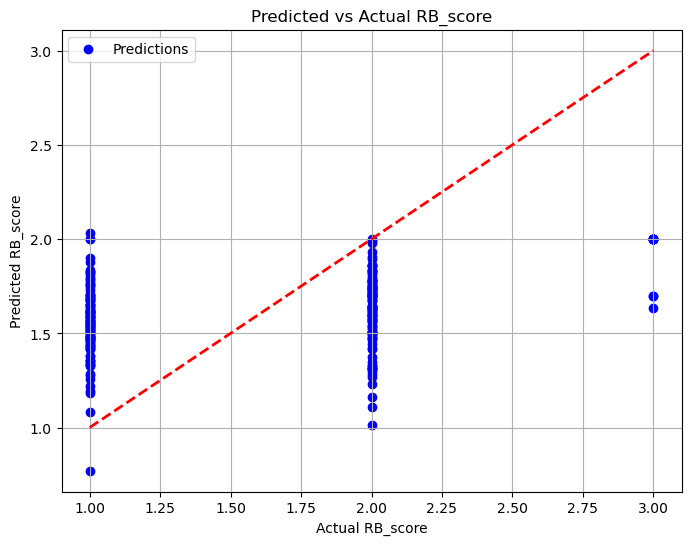

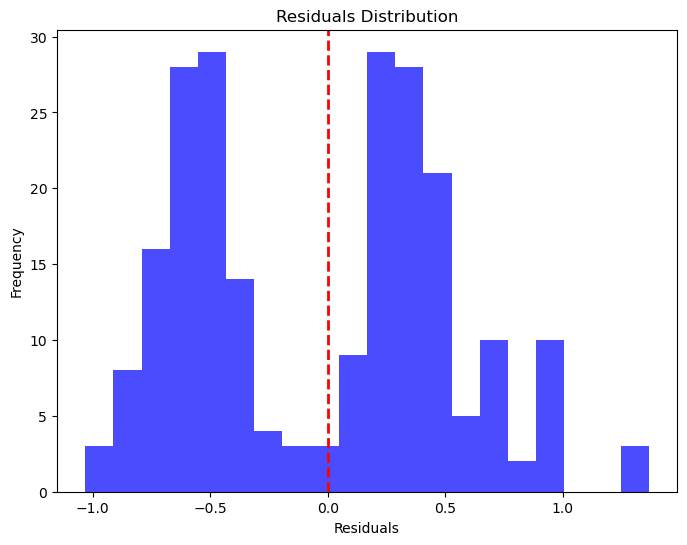

In [189]:

# Step 3: Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict on Test Data
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

Mean Squared Error: 0.3066799018260826


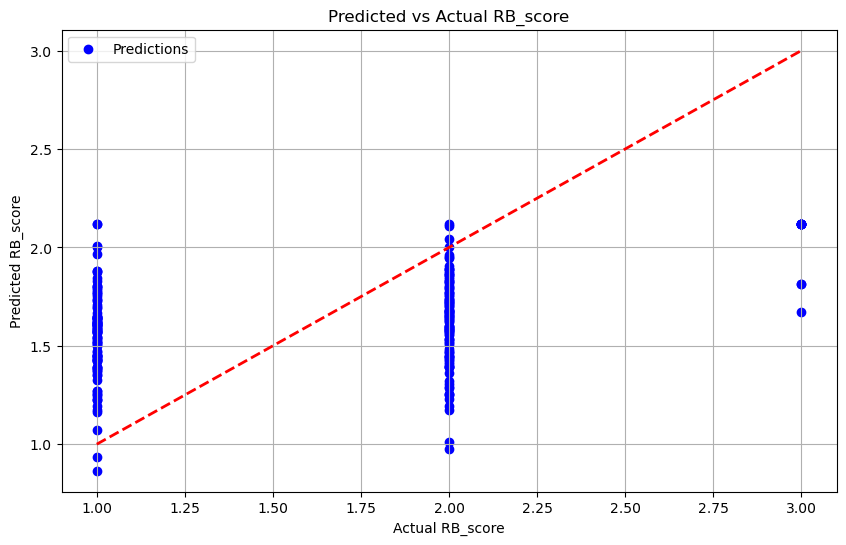

In [191]:
# Density + layers
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
y = df_raw['RB_score_grouped'].values

# Combine the two features into one array (horizontal stacking)
X = np.concatenate((X_layers, X_density), axis=1)

# Split data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 3: Predictions and Evaluation
y_pred = model.predict(X_test)

# Calculate and print the Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Optional: Visualize Predictions vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

Root Mean Squared Error: 0.5556638287109311


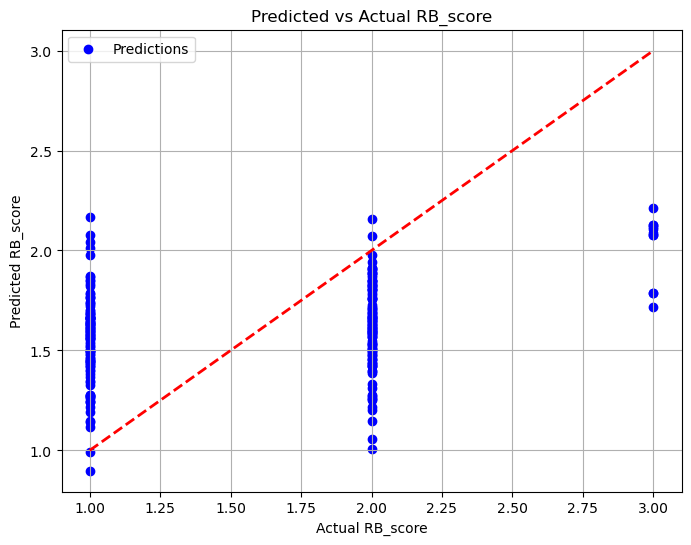

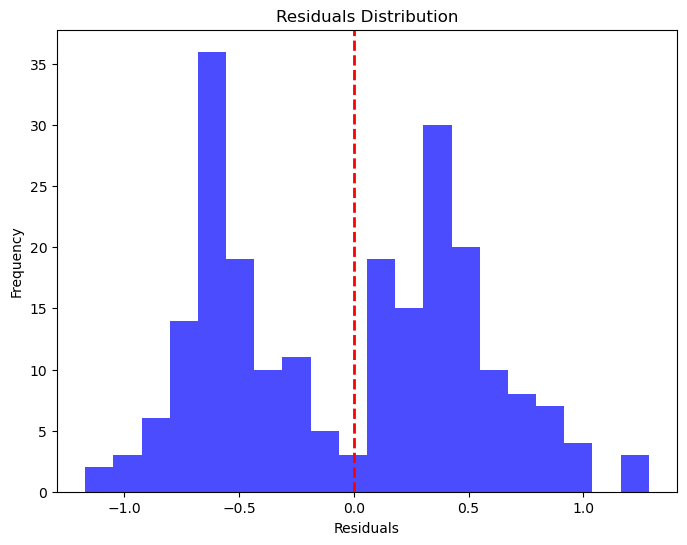

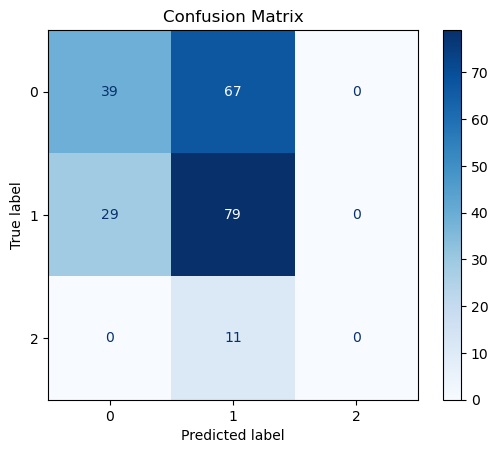

In [194]:
# Define the truncate length (ensure this matches your data preparation)
truncate = 10  # Modify as needed

# Convert the lists to a NumPy array
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
y = df_raw['RB_score_grouped'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle))  # Add slope_angle as a feature

# Split data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict on Test Data
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Root Mean Squared Error: 0.4567310901385785


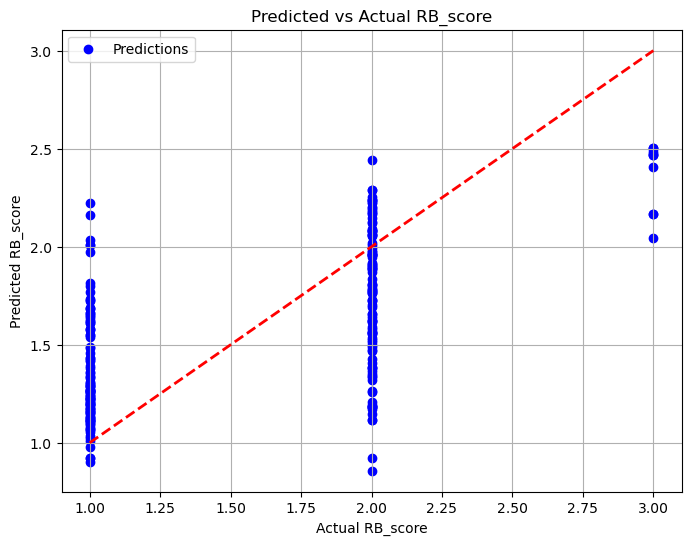

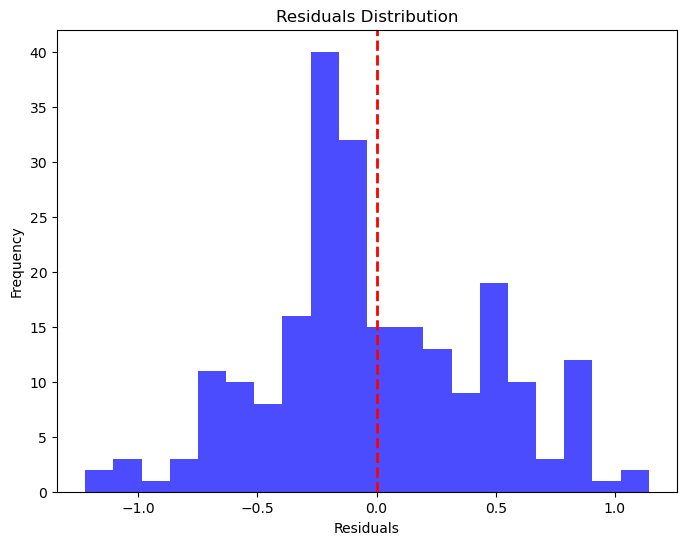

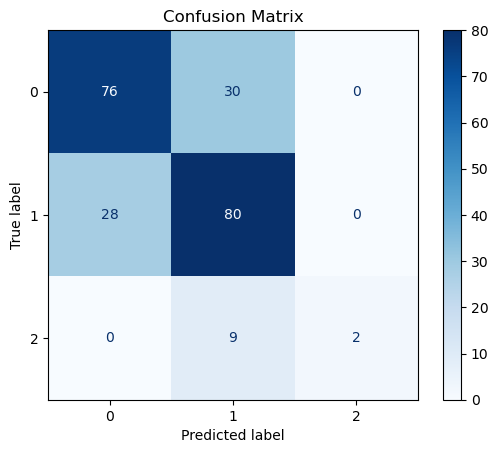

In [195]:
# + localNowcast
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
local_nowcast = df_raw['localNowcast'].values  # Assuming localNowcast is a column in df_raw
y = df_raw['RB_score_grouped'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Add localNowcast as a feature

# Split data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict on Test Data
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Root Mean Squared Error: 0.4567310901385785

Bootstrap Coefficients with 95% Confidence Intervals:
Feature 0: Mean=-0.0020, 95% CI=(-0.0056, 0.0018)
Feature 1: Mean=0.0031, 95% CI=(-0.0008, 0.0069)
Feature 2: Mean=0.0033, 95% CI=(-0.0023, 0.0084)
Feature 3: Mean=0.0000, 95% CI=(-0.0058, 0.0061)
Feature 4: Mean=0.0038, 95% CI=(0.0006, 0.0066)
Feature 5: Mean=-0.0017, 95% CI=(-0.0023, -0.0011)
Feature 6: Mean=-0.0011, 95% CI=(-0.0018, -0.0005)
Feature 7: Mean=-0.0001, 95% CI=(-0.0007, 0.0005)
Feature 8: Mean=0.0005, 95% CI=(-0.0002, 0.0012)
Feature 9: Mean=0.0006, 95% CI=(-0.0002, 0.0013)
Feature 10: Mean=-0.0075, 95% CI=(-0.0170, 0.0021)
Feature 11: Mean=-0.4480, 95% CI=(-0.4925, -0.3977)


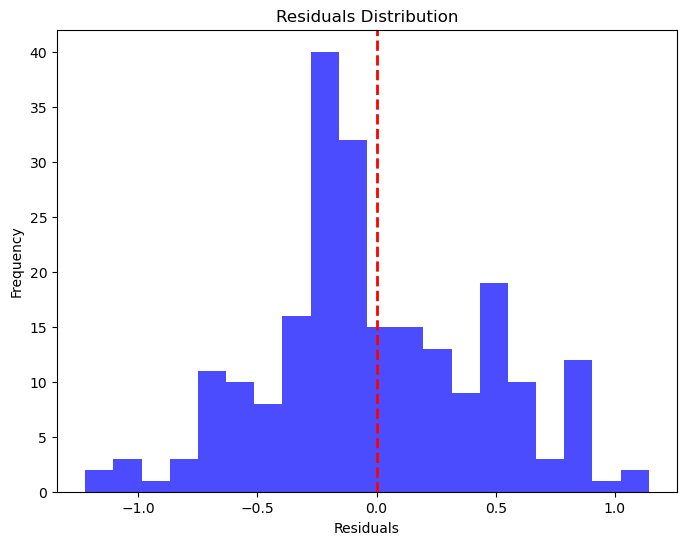

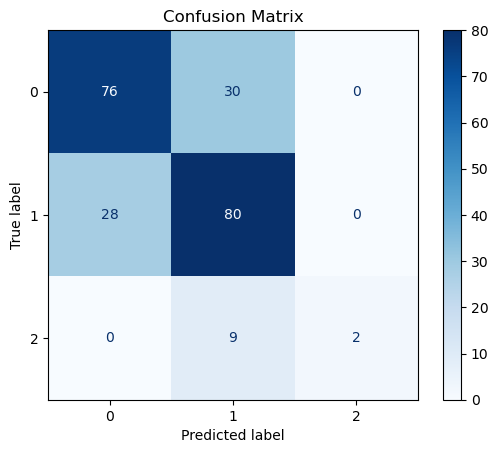

In [212]:
# Now redo to find confidence intervals:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Assume df_raw is your DataFrame and has been pre-processed already
# + localNowcast
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
local_nowcast = df_raw['localNowcast'].values  # Assuming localNowcast is a column in df_raw
y = df_raw['RB_score_grouped'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Add localNowcast as a feature

# Split data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 1: Train the model once and report results
model = LinearRegression()
model.fit(X_train, y_train)

# Get predictions and evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

# Step 2: Bootstrapping for Confidence Intervals
n_bootstraps = 1000  # Number of bootstrap samples
coefficients = np.zeros((n_bootstraps, X_train.shape[1]))  # Store coefficients from each bootstrap

# Bootstrapping loop
for i in range(n_bootstraps):
    # Resample with replacement from the training data
    X_train_boot, y_train_boot = resample(X_train, y_train, random_state=i)
    
    # Fit the model on the bootstrap sample
    model_boot = LinearRegression()
    model_boot.fit(X_train_boot, y_train_boot)
    
    # Store the coefficients
    coefficients[i, :] = model_boot.coef_

# Step 3: Calculate Confidence Intervals
lower_bound = np.percentile(coefficients, 2.5, axis=0)
upper_bound = np.percentile(coefficients, 97.5, axis=0)
mean_coefficients = np.mean(coefficients, axis=0)

# Print the coefficient estimates with confidence intervals
print("\nBootstrap Coefficients with 95% Confidence Intervals:")
for idx, coef in enumerate(mean_coefficients):
    print(f'Feature {idx}: Mean={coef:.4f}, 95% CI=({lower_bound[idx]:.4f}, {upper_bound[idx]:.4f})')

# Step 4: Plot Residuals (as before)
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 5: Confusion Matrix (For Binary Classification)
y_pred_binary = np.round(y_pred).astype(int)
y_test_binary = np.round(y_test).astype(int)
cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Root Mean Squared Error: 0.5838369673633538


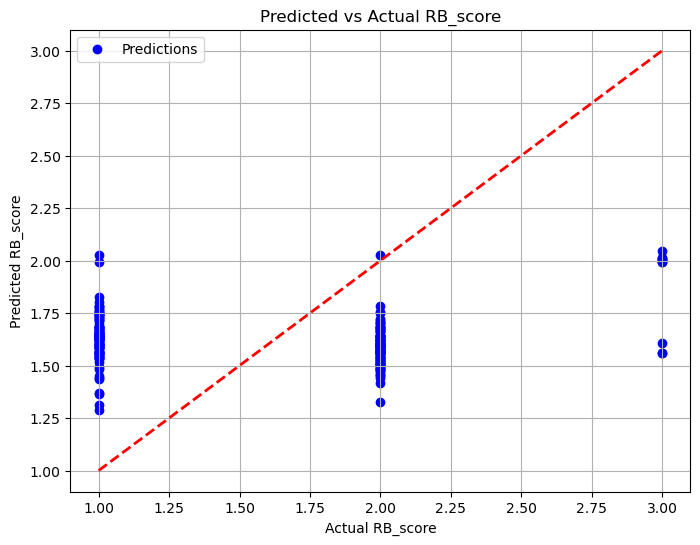

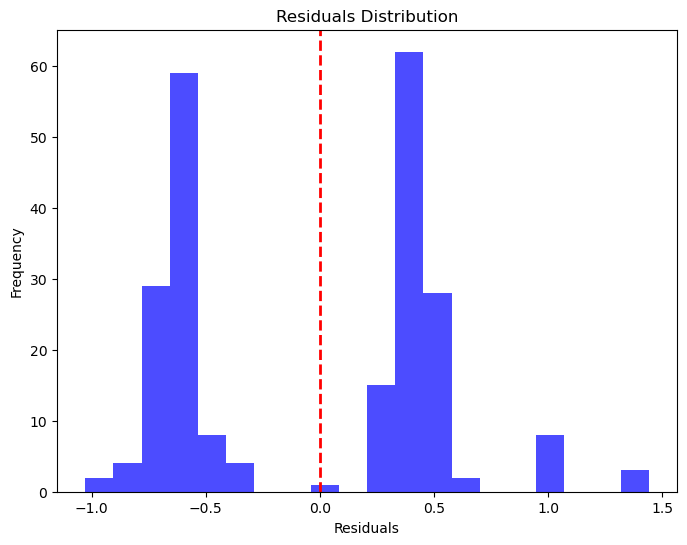

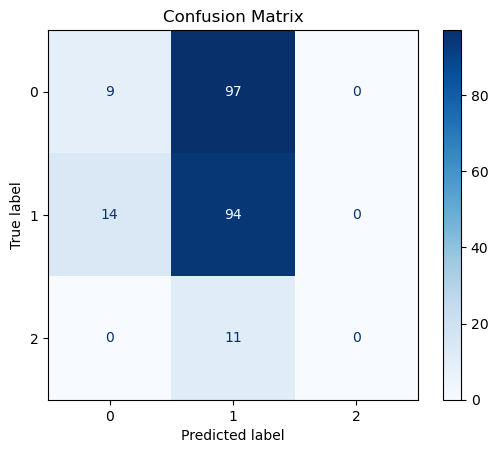

In [223]:
# Now use one representaion of density and layers
# Convert the lists to a NumPy array
# X_layers = np.array(df_raw['mass_above_wl'].tolist())
X_density = np.array(df_raw['one_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
y = df_raw['RB_score_grouped'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_density,  slope_angle))  # Add slope_angle as a feature

# Split data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict on Test Data
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Root Mean Squared Error: 0.6574682303565741


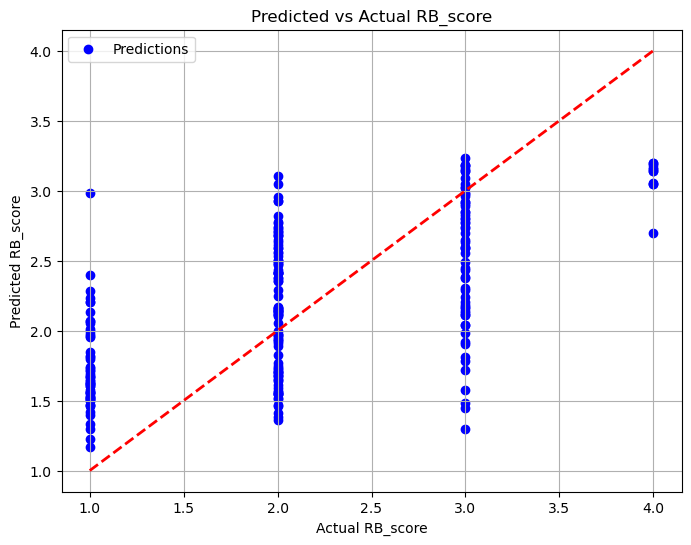

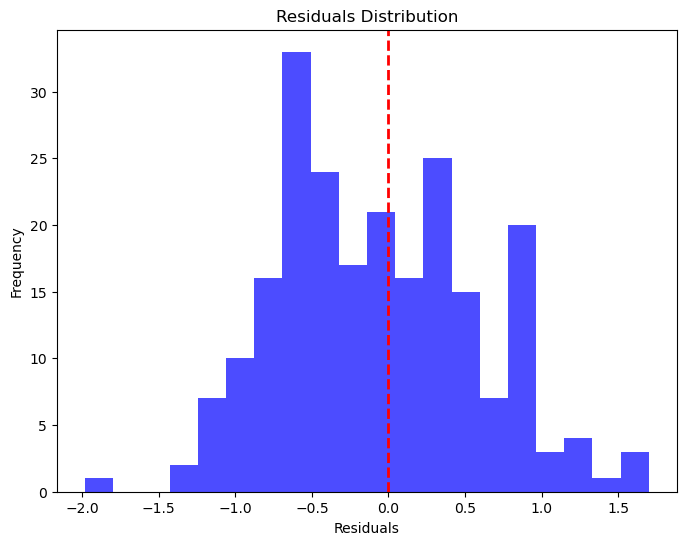

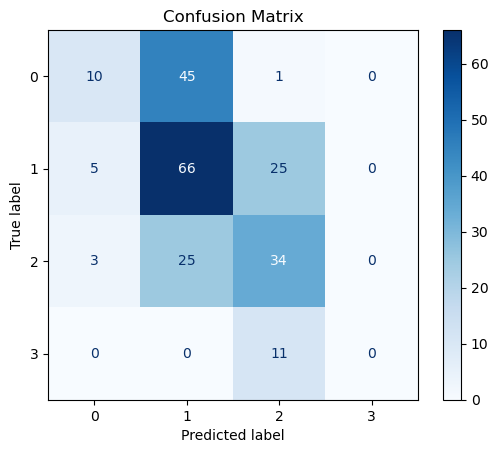

In [210]:
# + localNowcast but four segments
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
local_nowcast = df_raw['localNowcast'].values  # Assuming localNowcast is a column in df_raw
y = df_raw['RB_score_grouped_4'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Add localNowcast as a feature

# Split data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict on Test Data
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [211]:
##### ABOVE IS LATEST VERSION OF JUST SIMPLE REGRESSION MODELLING ####### Four groups is handled poorly, three groups look somewhat white-resembling.

Root Mean Squared Error: 0.4337925771610206


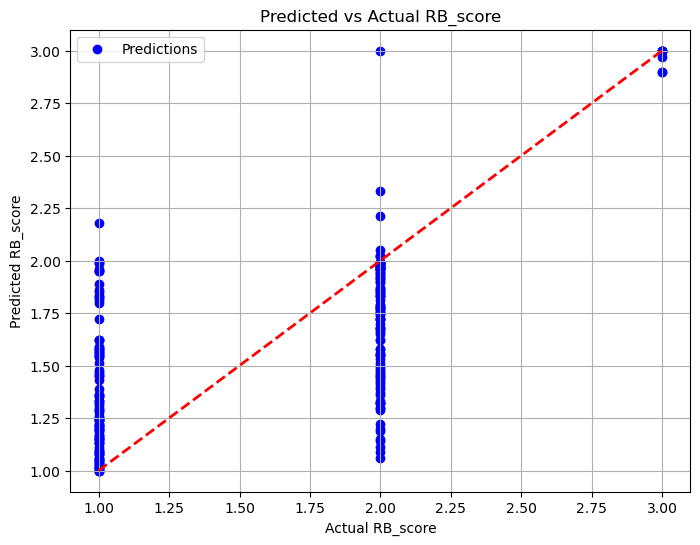

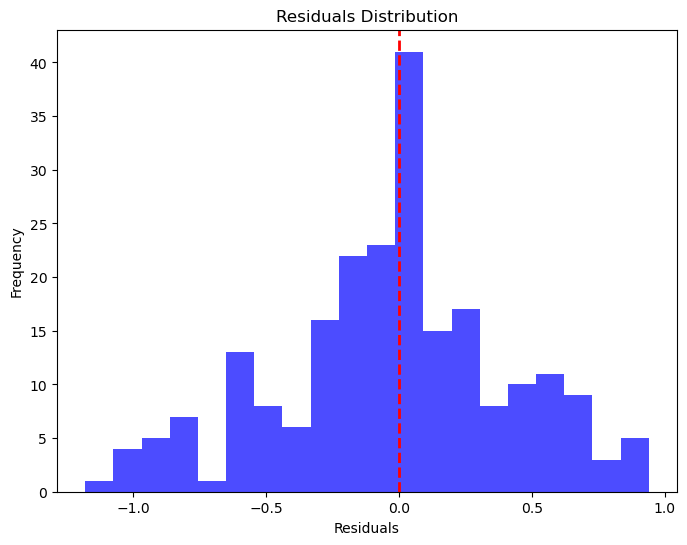

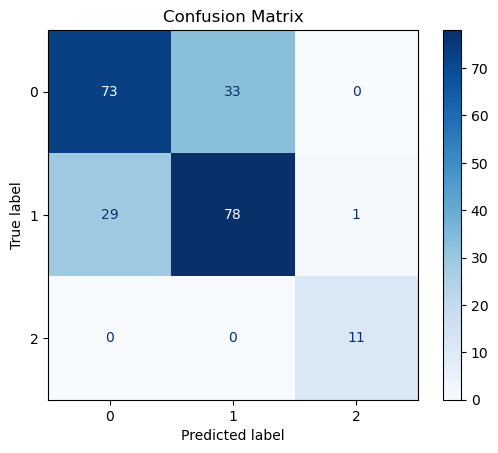

In [199]:
# We now try Random Forest Regressor
# Define the truncate length (ensure this matches your data preparation)
truncate = 10  # Modify as needed

# Convert the lists to a NumPy array
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
local_nowcast = df_raw['localNowcast'].values  # Assuming localNowcast is a column in df_raw
y = df_raw['RB_score_grouped'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Add localNowcast as a feature

# Split data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Build and Train the Random Forest Model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can adjust n_estimators
model.fit(X_train, y_train)

# Step 4: Predict on Test Data
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# This is starting to look good

/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
79 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 1144, in wrapper
    estimator._validate_params()
  File "/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 637, in _validate_params
    validate_parameter_constraints(
  File "

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Root Mean Squared Error: 0.4253359389463956


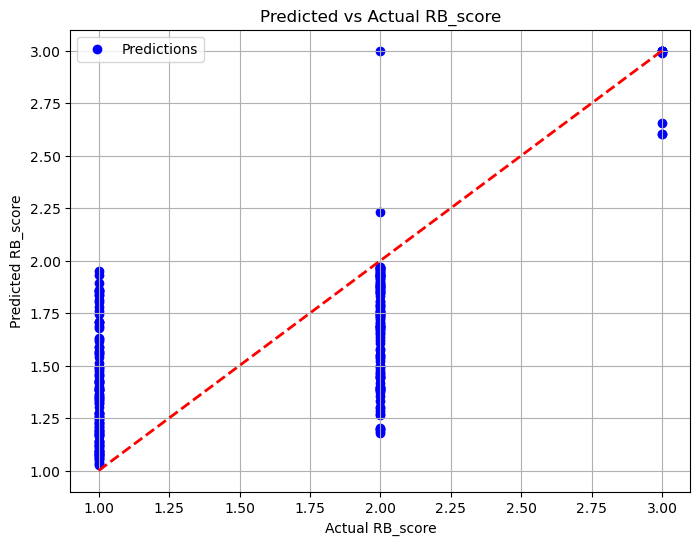

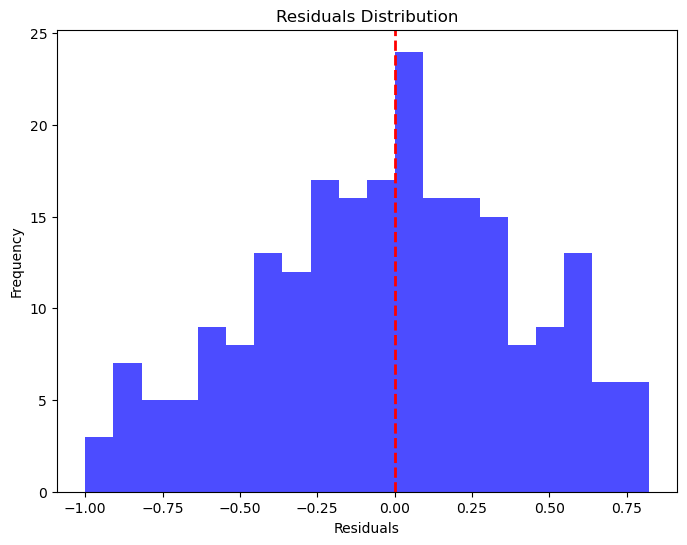

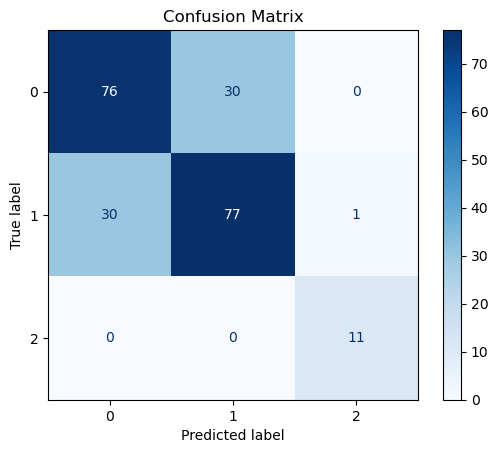

In [200]:
# Hyperparameter tuning introduced
# Define the truncate length (ensure this matches your data preparation)
truncate = 10  # Modify as needed

# Assuming df_raw is your DataFrame with the necessary columns
# Convert the lists to a NumPy array
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
local_nowcast = df_raw['localNowcast'].values  # Assuming localNowcast is a column in df_raw
y = df_raw['RB_score_grouped'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Add localNowcast as a feature

# Split data into training and testing sets (70% training, 30% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Hyperparameter Tuning using GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Instantiate the model
rf_model = RandomForestRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(rf_model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Step 4: Predict on Test Data using the best model
y_pred = best_model.predict(X_test)

# Step 5: Evaluate the Model
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# We slightly improve the looks of the residuals, now try Gradient Booster


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50, 'subsample': 0.8}
Root Mean Squared Error: 0.4208125619738483


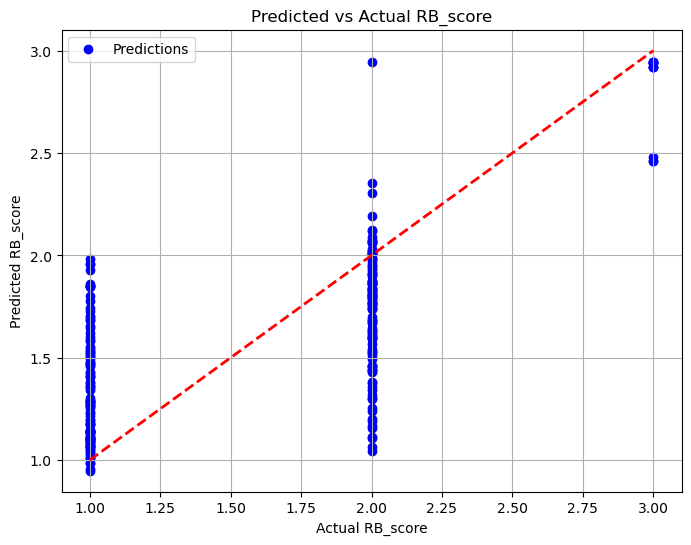

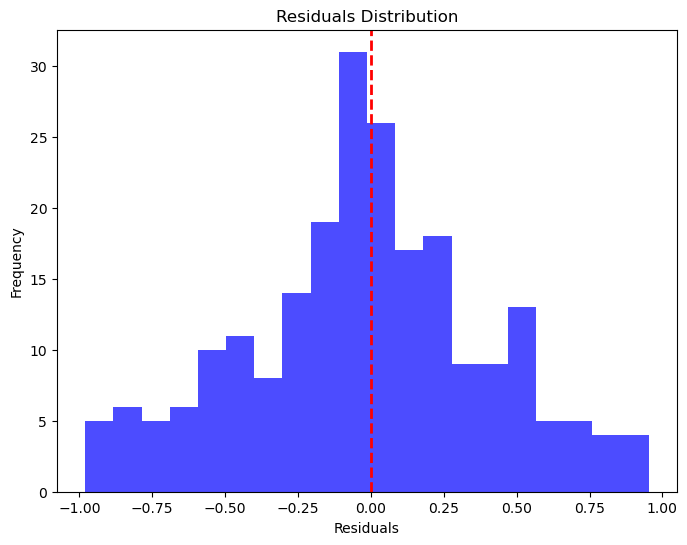

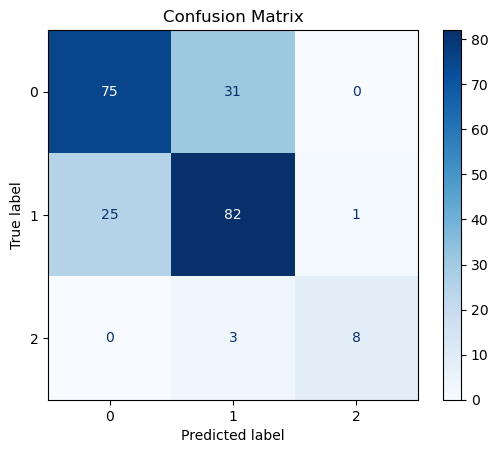

In [201]:
# Define the truncate length (ensure this matches your data preparation)
truncate = 10  # Modify as needed

# Assuming df_raw is your DataFrame with the necessary columns
# Convert the lists to a NumPy array
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
local_nowcast = df_raw['localNowcast'].values  # Assuming localNowcast is a column in df_raw
y = df_raw['RB_score_grouped'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Add localNowcast as a feature

# Split data into training and testing sets (70% training, 30% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Hyperparameter Tuning using GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

# Instantiate the model
gb_model = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(gb_model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Step 4: Predict on Test Data using the best model
y_pred = best_model.predict(X_test)

# Step 5: Evaluate the Model
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50, 'subsample': 1.0}
Root Mean Squared Error: 0.7093765891394392


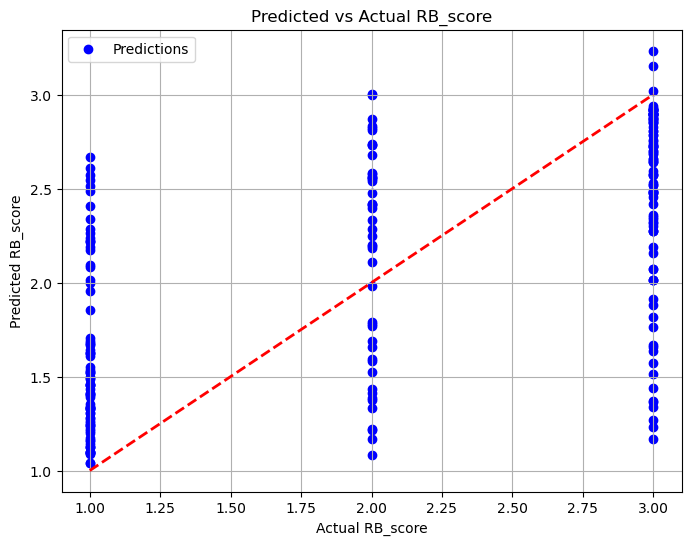

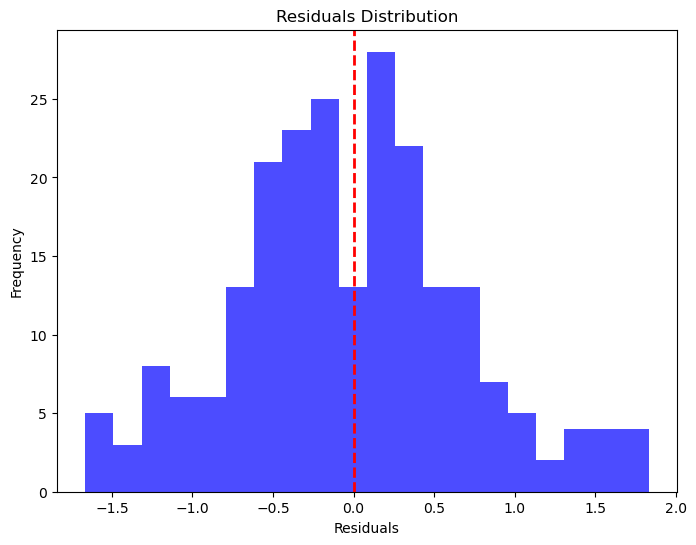

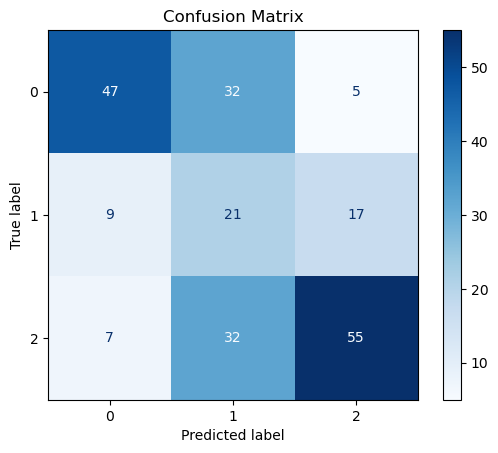

In [202]:
# Also rather good performance, proceed to try and model RB_class instead and see if it works

# Define the truncate length (ensure this matches your data preparation)
truncate = 10  # Modify as needed

# Assuming df_raw is your DataFrame with the necessary columns
# Convert the lists to a NumPy array
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
local_nowcast = df_raw['localNowcast'].values  # Assuming localNowcast is a column in df_raw
y = df_raw['RB_class'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Add localNowcast as a feature

# Split data into training and testing sets (70% training, 30% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Hyperparameter Tuning using GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

# Instantiate the model
gb_model = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(gb_model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Step 4: Predict on Test Data using the best model
y_pred = best_model.predict(X_test)

# Step 5: Evaluate the Model
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Did not go as well, because RB_class might just be the wrong type of capture. We now try to full seven steps, without grouping to see how we perform

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50, 'subsample': 0.8}
Root Mean Squared Error: 1.1385918276163642


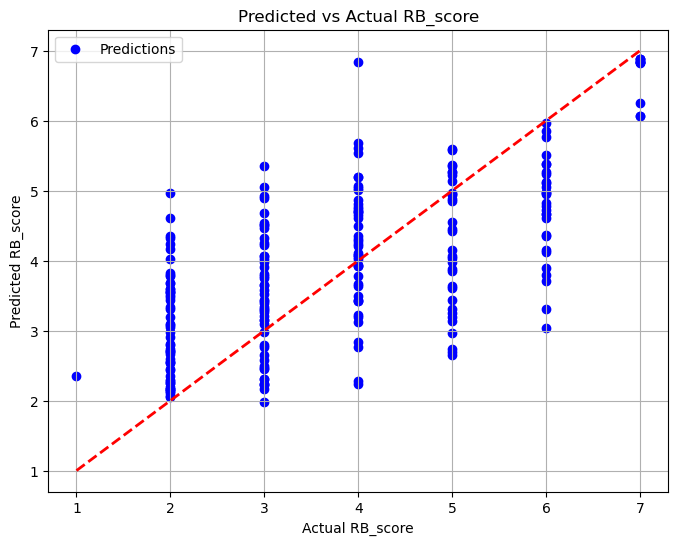

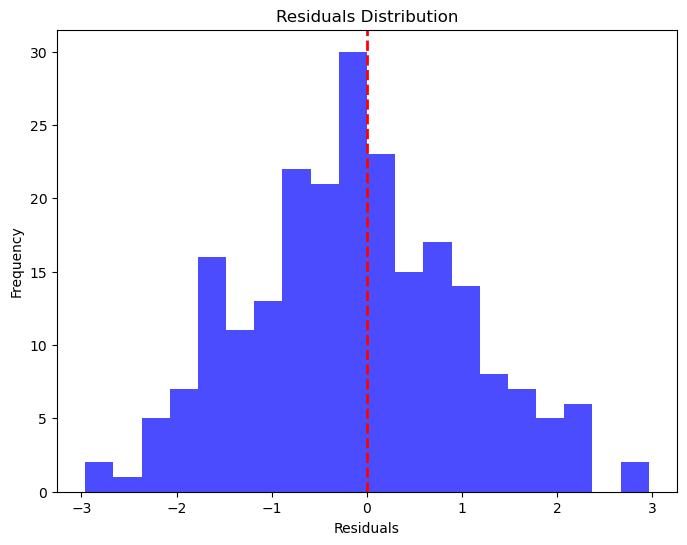

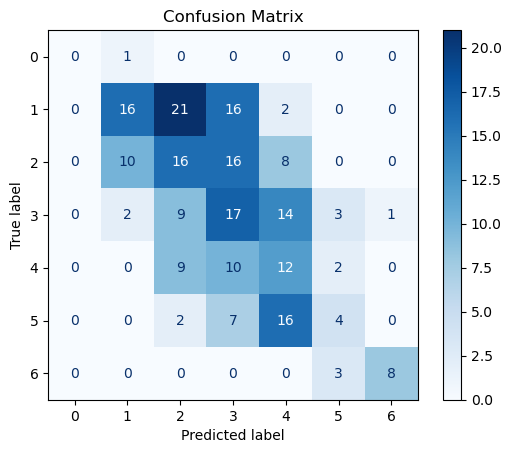

In [203]:
# Define the truncate length (ensure this matches your data preparation)
truncate = 10  # Modify as needed

# Assuming df_raw is your DataFrame with the necessary columns
# Convert the lists to a NumPy array
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
local_nowcast = df_raw['localNowcast'].values  # Assuming localNowcast is a column in df_raw
y = df_raw['RB_score'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Add localNowcast as a feature

# Split data into training and testing sets (70% training, 30% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Hyperparameter Tuning using GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

# Instantiate the model
gb_model = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(gb_model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Step 4: Predict on Test Data using the best model
y_pred = best_model.predict(X_test)

# Step 5: Evaluate the Model
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50, 'subsample': 1.0}
Root Mean Squared Error: 0.6794333151033544


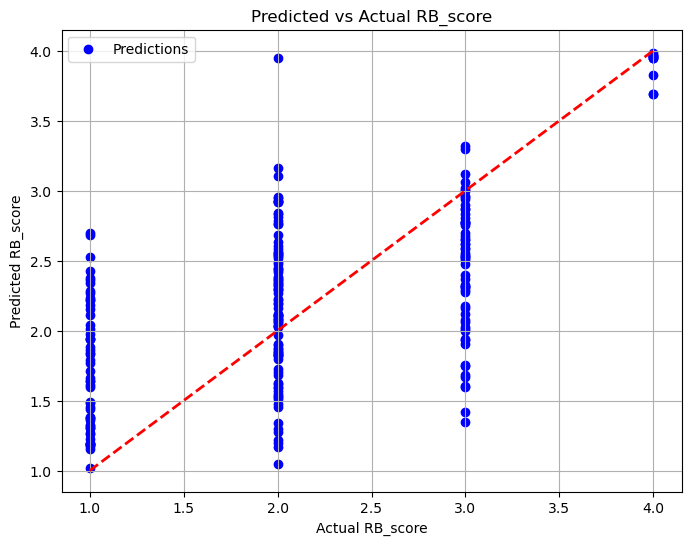

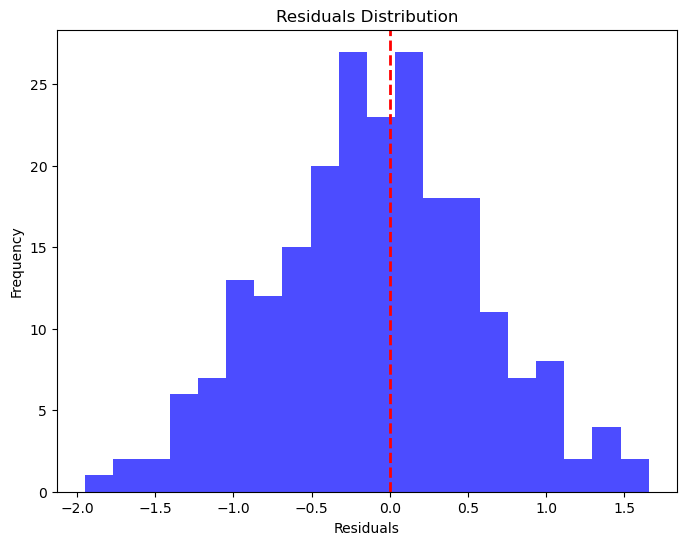

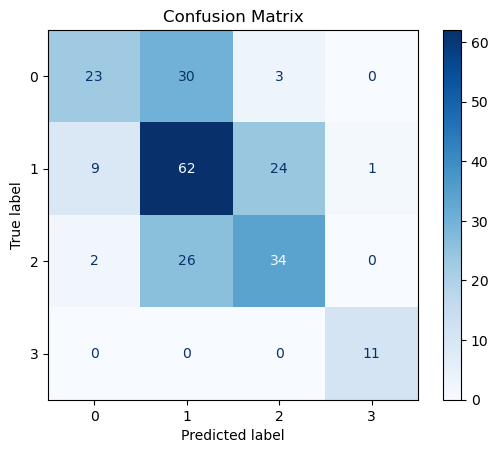

In [209]:
# Try with four groups instead of three
# Define the truncate length (ensure this matches your data preparation)
truncate = 10  # Modify as needed

# Assuming df_raw is your DataFrame with the necessary columns
# Convert the lists to a NumPy array
X_layers = np.array(df_raw['trunc_layers_above_wl'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl'].tolist())
slope_angle = df_raw['slopeangle'].values  # Assuming slopeangle is a column in df_raw
local_nowcast = df_raw['localNowcast'].values  # Assuming localNowcast is a column in df_raw
y = df_raw['RB_score_grouped_4'].values

# Combine the features into one array (horizontal stacking)
X = np.column_stack((X_layers, X_density, slope_angle, local_nowcast))  # Add localNowcast as a feature

# Split data into training and testing sets (70% training, 30% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Hyperparameter Tuning using GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

# Instantiate the model
gb_model = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(gb_model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Step 4: Predict on Test Data using the best model
y_pred = best_model.predict(X_test)

# Step 5: Evaluate the Model
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Predicted vs Actual Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 7: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='blue')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Step 8: Confusion Matrix (For Binary Classification)
# Round the predictions to convert them to binary
y_pred_binary = np.round(y_pred).astype(int)  # Round predictions to nearest integer
y_test_binary = np.round(y_test).astype(int)  # Round actual values to nearest integer

# Calculate the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


RMSE: 1.544


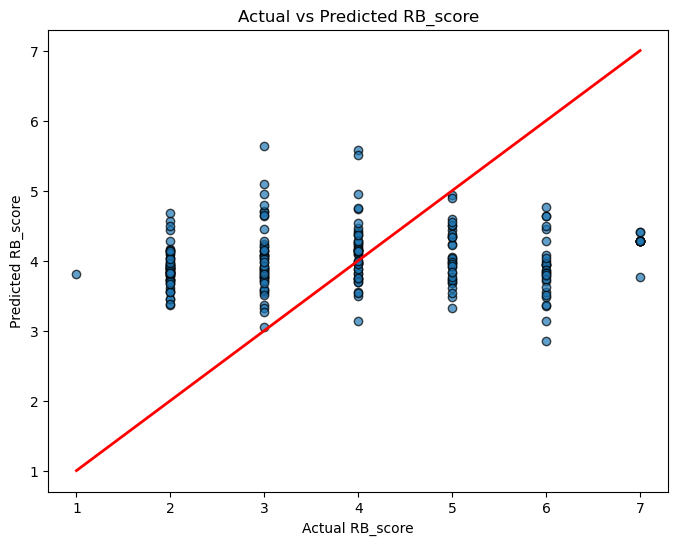

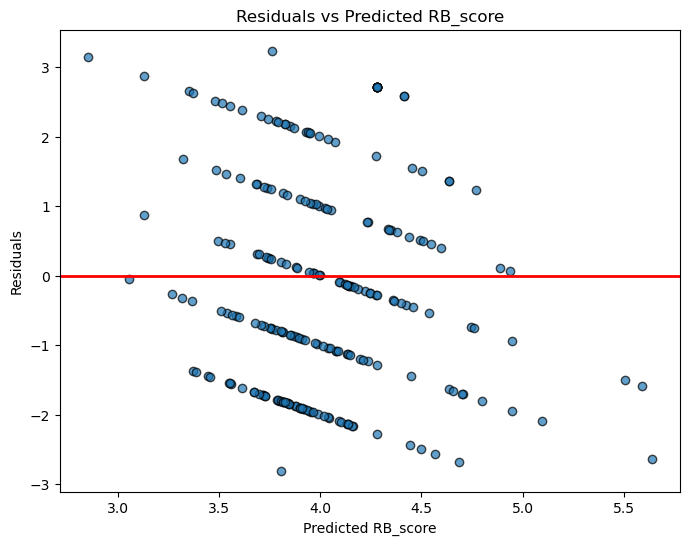

In [196]:
# Really poor performance, we test predicting of RB_score instead
# Step 1: Preprocess trunc_layers_above_wl - Padding with zeros to ensure same length
# Assuming `trunc_layers_above_wl` is a column in df_raw and it's a list or array-like feature.

# Find the maximum length of the sequences in `trunc_layers_above_wl`
max_len = df_raw['trunc_layers_above_wl'].apply(len).max()

# Pad each entry in the column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Convert the padded lists into numpy arrays
X = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())

# Step 2: Change the target variable to 'RB_score'
# The target variable
y = df_raw['RB_score'].values  # Change this line to use RB_score instead of RB_class

# Step 3: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Build a simple regression model
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")

# Step 6: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.title('Actual vs Predicted RB_score')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_score')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_score')
plt.show()


RMSE: 0.848

Confusion Matrix:
[[ 3 80  1]
 [ 0 44  3]
 [ 1 87  6]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.75      0.04      0.07        84
         2.0       0.21      0.94      0.34        47
         3.0       0.60      0.06      0.12        94

    accuracy                           0.24       225
   macro avg       0.52      0.35      0.17       225
weighted avg       0.57      0.24      0.14       225



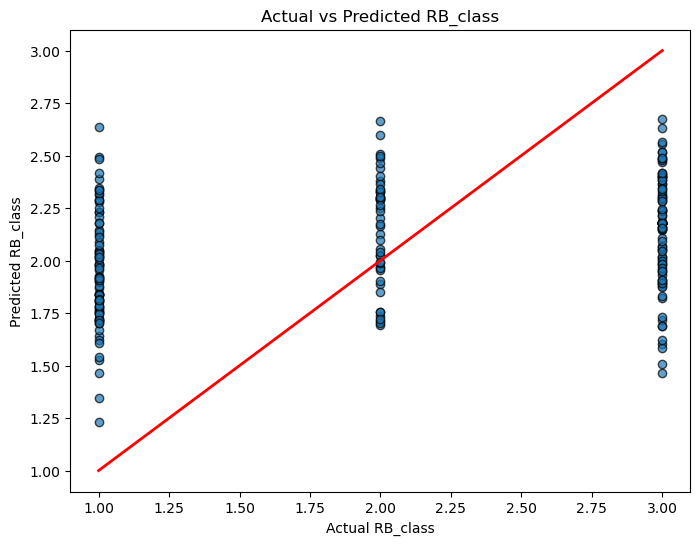

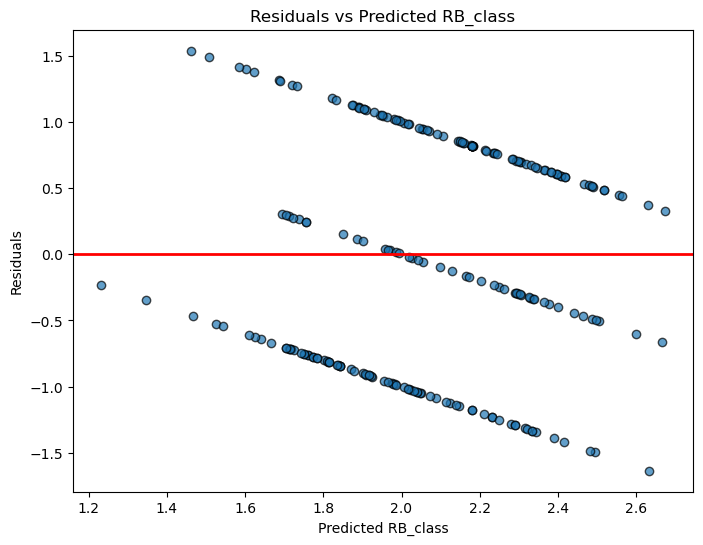

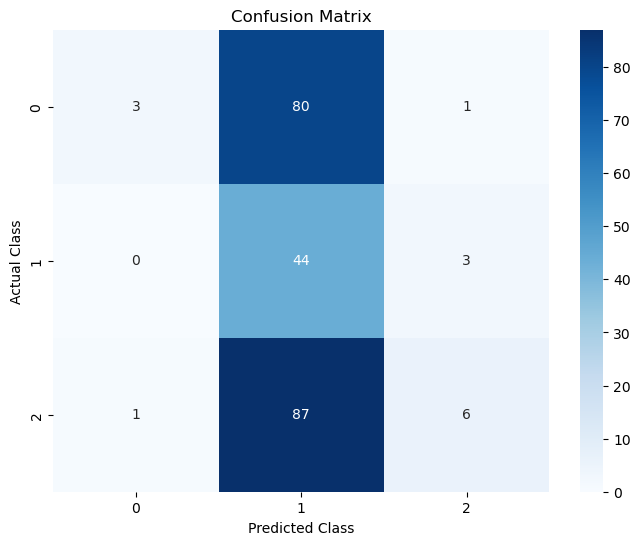

In [197]:
# Go back to RB_class, but now using density and layer thickness as input
# Step 1: Preprocess both trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length

# Find the maximum length of the sequences in both columns
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()

# Determine the maximum length to pad both sequences
max_len = max(max_len_layers, max_len_density)

# Pad each entry in the trunc_layers_above_wl column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Pad each entry in the trunc_density_above_wl column to the maximum length with zeros
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Combine both padded arrays into a single feature array
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Stack the two features horizontally
X = np.hstack((X_layers, X_density))  # Combine both features into a single 2D array

# Step 2: Define the target variable
y = df_raw['RB_class'].values  # Change this line to use RB_class

# Step 3: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Build a simple regression model
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Confusion Matrix (for classification, round predictions to nearest integer)
y_pred_class = np.round(y_pred).astype(int)
conf_matrix = confusion_matrix(y_val, y_pred_class)

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_class))

# Step 6: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_class')
plt.ylabel('Predicted RB_class')
plt.title('Actual vs Predicted RB_class')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_class')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_class')
plt.show()

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

RMSE: 0.850

Confusion Matrix:
[[ 3 80  1]
 [ 0 44  3]
 [ 0 88  6]]

Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      0.04      0.07        84
         2.0       0.21      0.94      0.34        47
         3.0       0.60      0.06      0.12        94

    accuracy                           0.24       225
   macro avg       0.60      0.35      0.17       225
weighted avg       0.67      0.24      0.14       225



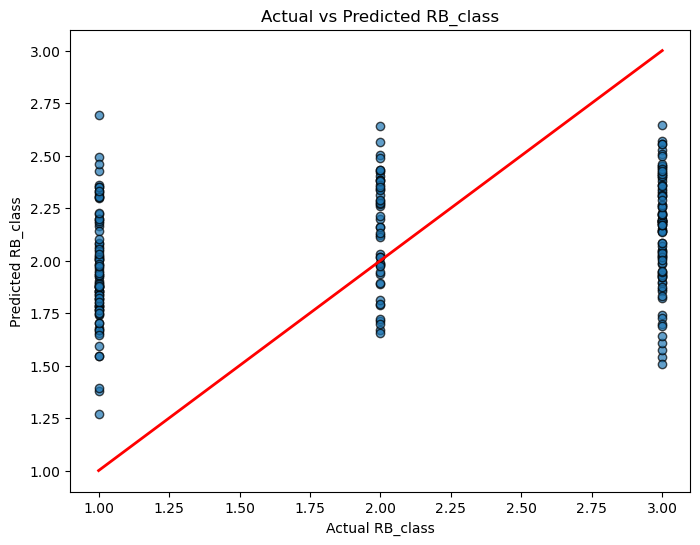

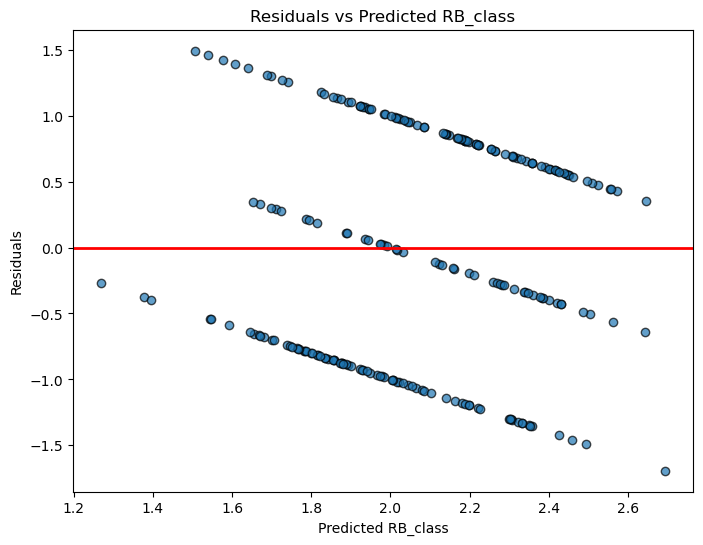

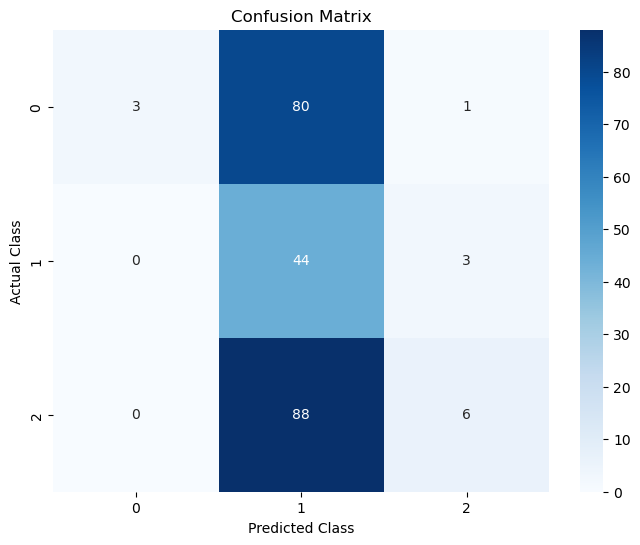

In [70]:
# We now try to predict RB_class, but allow the model to use slopeangle as well

# Combine both padded arrays into a single feature array
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Step 2: Extract the slopeangle as an additional feature
slopeangle = df_raw['slopeangle'].values.reshape(-1, 1)  # Reshape for horizontal stacking

# Stack the two features horizontally along with slopeangle
X = np.hstack((X_layers, X_density, slopeangle))  # Combine all features into a single 2D array

# Step 3: Define the target variable
y = df_raw['RB_class'].values  # The target variable remains RB_class

# Step 4: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Build a simple regression model
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Confusion Matrix (for classification, round predictions to nearest integer)
y_pred_class = np.round(y_pred).astype(int)
conf_matrix = confusion_matrix(y_val, y_pred_class)

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_class))

# Step 7: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_class')
plt.ylabel('Predicted RB_class')
plt.title('Actual vs Predicted RB_class')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_class')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_class')
plt.show()

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()


RMSE: 1.457


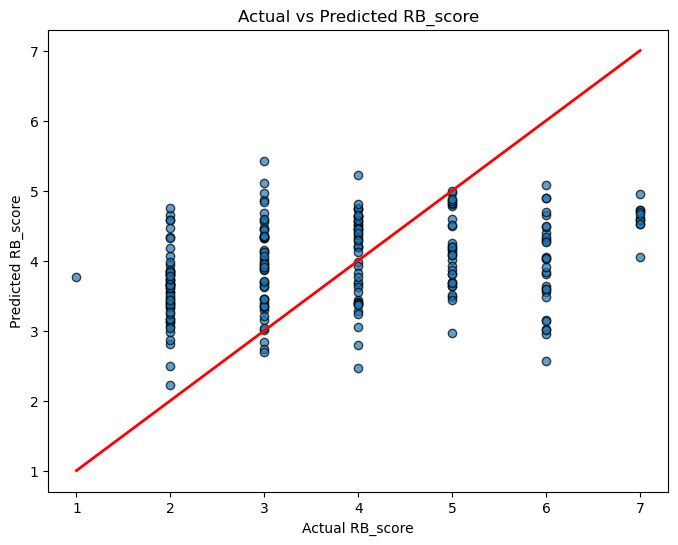

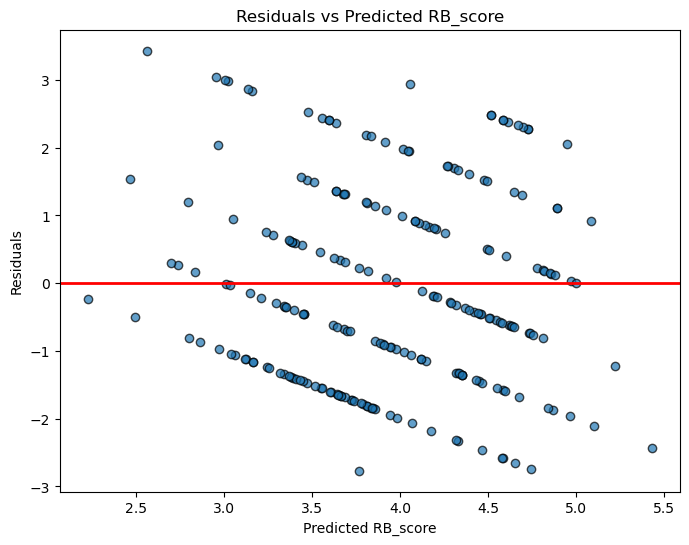

In [71]:
# Predicting RB_score instead
# Step 1: Preprocess both trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length

# Combine both padded arrays into a single feature array
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Step 2: Extract the slopeangle as an additional feature
slopeangle = df_raw['slopeangle'].values.reshape(-1, 1)  # Reshape for horizontal stacking

# Stack the two features horizontally along with slopeangle
X = np.hstack((X_layers, X_density, slopeangle))  # Combine all features into a single 2D array

# Step 3: Define the target variable
y = df_raw['RB_score'].values  # Change this line to use RB_score

# Step 4: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Build a simple regression model
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")

# Step 7: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.title('Actual vs Predicted RB_score')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_score')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_score')
plt.show()


In [96]:
# Combine both padded arrays into a single feature array
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Step 2: Extract the slopeangle and localNowcast as additional features
slopeangle = df_raw['slopeangle'].values.reshape(-1, 1)  # Reshape for horizontal stacking
localNowcast = df_raw['localNowcast'].values.reshape(-1, 1)  # Reshape for horizontal stacking

# Stack the features horizontally along with slopeangle and localNowcast
X = np.hstack((X_layers, X_density, slopeangle, localNowcast))  # Combine all features into a single 2D array

# Step 3: Define the target variable
y = df_raw['RB_score'].values  # The target variable remains RB_score

# Step 4: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Build a simple regression model
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")

# Step 7: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.title('Actual vs Predicted RB_score')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_score')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_score')
plt.show()


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (748,) + inhomogeneous part.

RMSE: 1.160


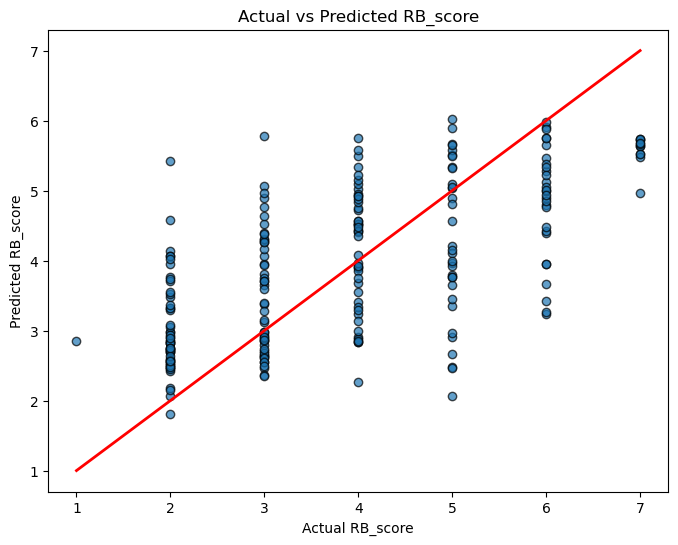

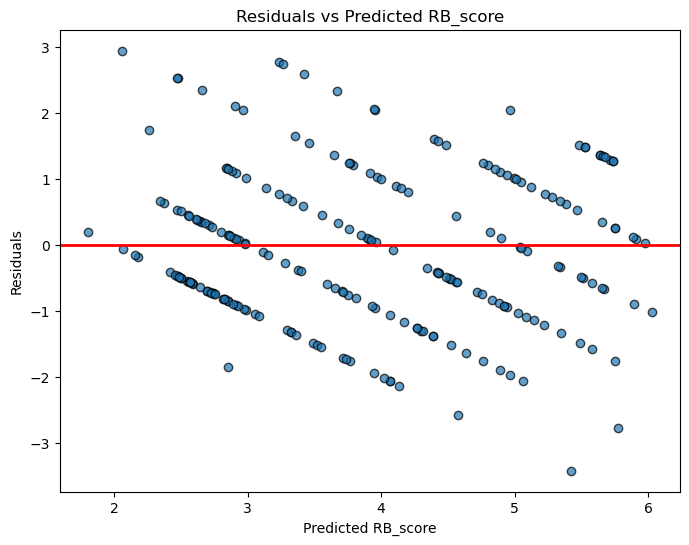

In [73]:
# Step 1: Preprocess both trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length

# Find the maximum length of the sequences in both columns
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()

# Determine the maximum length to pad both sequences
max_len = max(max_len_layers, max_len_density)

# Pad each entry in the trunc_layers_above_wl column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Pad each entry in the trunc_density_above_wl column to the maximum length with zeros
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Handle NaN values in wl_thickness by filling them with the mean value of the column
mean_wl_thickness = df_raw['wl_thickness'].mean()
df_raw['wl_thickness'].fillna(mean_wl_thickness, inplace=True)  # Fill NaNs with the mean

# Combine both padded arrays into a single feature array
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Step 2: Extract slopeangle, localNowcast, and wl_thickness as additional features
slopeangle = df_raw['slopeangle'].values.reshape(-1, 1)  # Reshape for horizontal stacking
localNowcast = df_raw['localNowcast'].values.reshape(-1, 1)  # Reshape for horizontal stacking
wl_thickness = df_raw['wl_thickness'].values.reshape(-1, 1)  # Reshape for horizontal stacking

# Stack the features horizontally along with slopeangle, localNowcast, and wl_thickness
X = np.hstack((X_layers, X_density, slopeangle, localNowcast, wl_thickness))  # Combine all features into a single 2D array

# Step 3: Define the target variable
y = df_raw['RB_score'].values  # The target variable remains RB_score

# Step 4: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Build a simple regression model
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")

# Step 7: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.title('Actual vs Predicted RB_score')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_score')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_score')
plt.show()


RMSE: 0.702


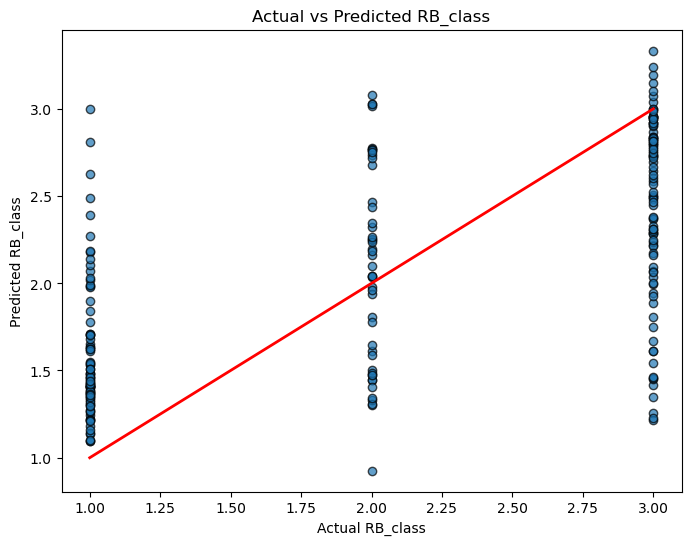

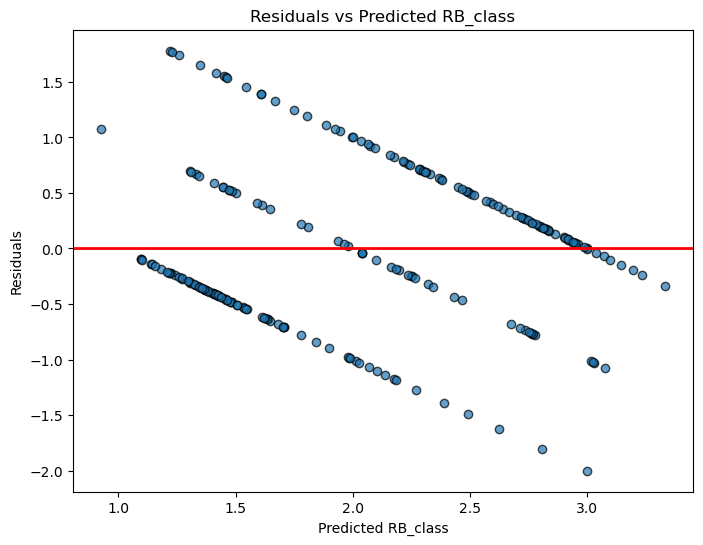

In [74]:
# Step 1: Preprocess both trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length

# Find the maximum length of the sequences in both columns
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()

# Determine the maximum length to pad both sequences
max_len = max(max_len_layers, max_len_density)

# Pad each entry in the trunc_layers_above_wl column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Pad each entry in the trunc_density_above_wl column to the maximum length with zeros
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Handle NaN values in wl_thickness by filling them with the mean value of the column
mean_wl_thickness = df_raw['wl_thickness'].mean()
df_raw['wl_thickness'].fillna(mean_wl_thickness, inplace=True)  # Fill NaNs with the mean

# Combine both padded arrays into a single feature array
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Step 2: Extract slopeangle, localNowcast, and wl_thickness as additional features
slopeangle = df_raw['slopeangle'].values.reshape(-1, 1)  # Reshape for horizontal stacking
localNowcast = df_raw['localNowcast'].values.reshape(-1, 1)  # Reshape for horizontal stacking
wl_thickness = df_raw['wl_thickness'].values.reshape(-1, 1)  # Reshape for horizontal stacking

# Stack the features horizontally along with slopeangle, localNowcast, and wl_thickness
X = np.hstack((X_layers, X_density, slopeangle, localNowcast, wl_thickness))  # Combine all features into a single 2D array

# Step 3: Define the target variable
y = df_raw['RB_class'].values  # The target variable is now RB_class

# Step 4: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Build a simple regression model (or classification if RB_class is categorical)
model = LinearRegression()  # Using Linear Regression, if RB_class is continuous
# If RB_class is categorical, consider using a classification model like LogisticRegression
# model = LogisticRegression()  # Uncomment this line if RB_class is categorical

# Fit the model
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)

# If RB_class is categorical, round predictions or use a threshold to classify
# y_pred_class = np.round(y_pred).astype(int)  # Uncomment this line if using classification

# Calculate RMSE (Root Mean Squared Error) if RB_class is continuous
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")

# Step 7: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_class')
plt.ylabel('Predicted RB_class')
plt.title('Actual vs Predicted RB_class')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_class')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_class')
plt.show()



Confusion Matrix:
[[69  3 12]
 [18  2 27]
 [16  2 76]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.67      0.82      0.74        84
         2.0       0.29      0.04      0.07        47
         3.0       0.66      0.81      0.73        94

    accuracy                           0.65       225
   macro avg       0.54      0.56      0.51       225
weighted avg       0.59      0.65      0.59       225



/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


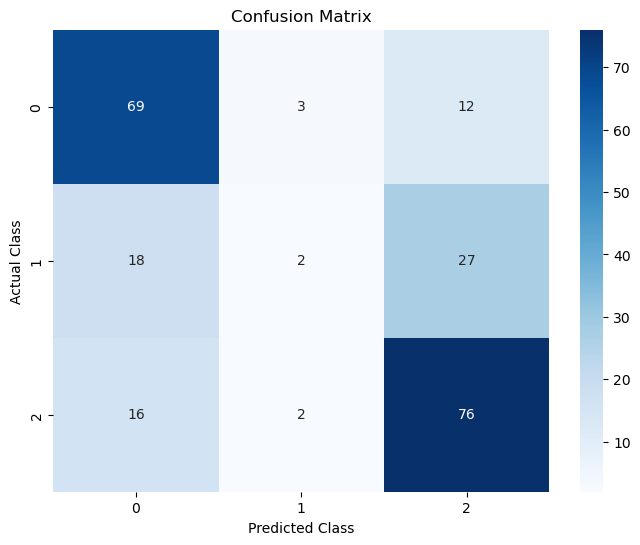

In [75]:
# Adding logistic regression and confusion matrix

# Step 1: Preprocess both trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length

# Find the maximum length of the sequences in both columns
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()

# Determine the maximum length to pad both sequences
max_len = max(max_len_layers, max_len_density)

# Pad each entry in the trunc_layers_above_wl column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Pad each entry in the trunc_density_above_wl column to the maximum length with zeros
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Handle NaN values in wl_thickness by filling them with the mean value of the column
mean_wl_thickness = df_raw['wl_thickness'].mean()
df_raw['wl_thickness'].fillna(mean_wl_thickness, inplace=True)  # Fill NaNs with the mean

# Combine both padded arrays into a single feature array
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Step 2: Extract slopeangle, localNowcast, and wl_thickness as additional features
slopeangle = df_raw['slopeangle'].values.reshape(-1, 1)  # Reshape for horizontal stacking
localNowcast = df_raw['localNowcast'].values.reshape(-1, 1)  # Reshape for horizontal stacking
wl_thickness = df_raw['wl_thickness'].values.reshape(-1, 1)  # Reshape for horizontal stacking

# Stack the features horizontally along with slopeangle, localNowcast, and wl_thickness
X = np.hstack((X_layers, X_density, slopeangle, localNowcast, wl_thickness))  # Combine all features into a single 2D array

# Step 3: Define the target variable
y = df_raw['RB_class'].values  # The target variable is now RB_class

# Step 4: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Build a simple classification model
from sklearn.linear_model import LogisticRegression  # Import logistic regression

model = LogisticRegression(max_iter=1000)  # Using Logistic Regression for classification
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)  # Use predict for class labels

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred)

# Output model performance
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Step 7: Visualizations

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()


/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Confusion Matrix:
[[ 0  1  0  0  0  0  0]
 [ 0 35 12  2  4  2  0]
 [ 0 16 15  4 10  4  1]
 [ 0  5 15  4 16  5  1]
 [ 1  6  7  2  8  9  0]
 [ 1  1  1  7  8 11  0]
 [ 0  0  0  1  2  0  8]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         2.0       0.55      0.64      0.59        55
         3.0       0.30      0.30      0.30        50
         4.0       0.20      0.09      0.12        46
         5.0       0.17      0.24      0.20        33
         6.0       0.35      0.38      0.37        29
         7.0       0.80      0.73      0.76        11

    accuracy                           0.36       225
   macro avg       0.34      0.34      0.33       225
weighted avg       0.35      0.36      0.35       225



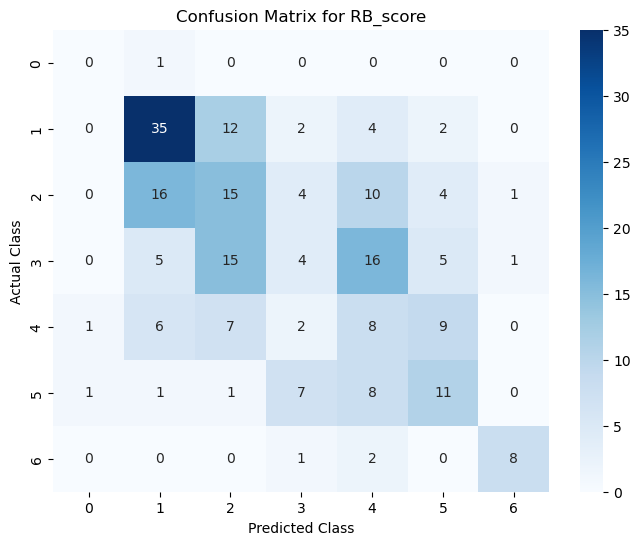

In [76]:
# Step 1: Preprocess both trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length

# Find the maximum length of the sequences in both columns
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()

# Determine the maximum length to pad both sequences
max_len = max(max_len_layers, max_len_density)

# Pad each entry in the trunc_layers_above_wl column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Pad each entry in the trunc_density_above_wl column to the maximum length with zeros
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Handle NaN values in wl_thickness by filling them with the mean value of the column
mean_wl_thickness = df_raw['wl_thickness'].mean()
df_raw['wl_thickness'].fillna(mean_wl_thickness, inplace=True)  # Fill NaNs with the mean

# Combine both padded arrays into a single feature array
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Step 2: Extract slopeangle, localNowcast, and wl_thickness as additional features
slopeangle = df_raw['slopeangle'].values.reshape(-1, 1)  # Reshape for horizontal stacking
localNowcast = df_raw['localNowcast'].values.reshape(-1, 1)  # Reshape for horizontal stacking
wl_thickness = df_raw['wl_thickness'].values.reshape(-1, 1)  # Reshape for horizontal stacking

# Stack the features horizontally along with slopeangle, localNowcast, and wl_thickness
X = np.hstack((X_layers, X_density, slopeangle, localNowcast, wl_thickness))  # Combine all features into a single 2D array

# Step 3: Define the target variable
y = df_raw['RB_score'].values  # The target variable is now RB_score

# Optional: Convert RB_score to categorical if it's not already (for example, using bins)
# If RB_score is continuous, you might need to bin it:
# bins = [0, 50, 100, 150, 200]  # Define your bins based on the RB_score distribution
# labels = [0, 1, 2, 3]  # Assign labels for the bins
# y = pd.cut(df_raw['RB_score'], bins=bins, labels=labels).astype(int)  # Binning RB_score into categories

# Step 4: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Build a simple classification model
from sklearn.linear_model import LogisticRegression  # Import logistic regression

model = LogisticRegression(max_iter=1000)  # Using Logistic Regression for classification
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)  # Use predict for class labels

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred)

# Output model performance
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Step 7: Visualizations

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix for RB_score')
plt.show()


/Users/carlwn/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Confusion Matrix:
[[79 26  1]
 [28 79  1]
 [ 0  3  8]]

Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.75      0.74       106
           2       0.73      0.73      0.73       108
           3       0.80      0.73      0.76        11

    accuracy                           0.74       225
   macro avg       0.76      0.73      0.75       225
weighted avg       0.74      0.74      0.74       225



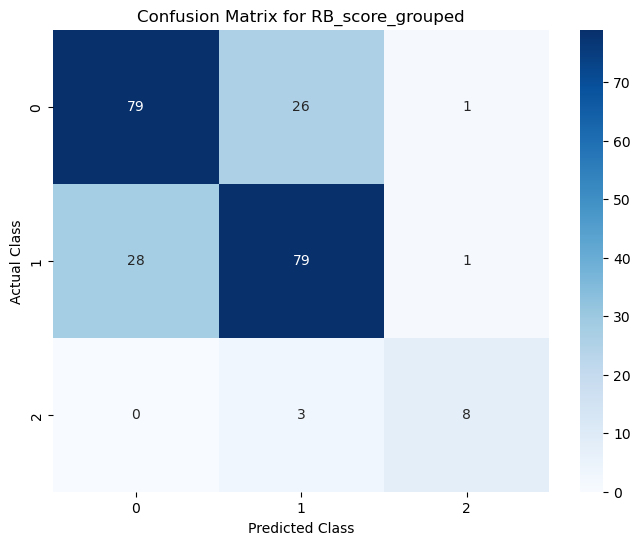

In [77]:
# Assuming df_raw has already been defined and contains the necessary columns

# Step 1: Preprocess both trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length

# Find the maximum length of the sequences in both columns
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()

# Determine the maximum length to pad both sequences
max_len = max(max_len_layers, max_len_density)

# Pad each entry in the trunc_layers_above_wl column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Pad each entry in the trunc_density_above_wl column to the maximum length with zeros
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Handle NaN values in wl_thickness by filling them with the mean value of the column
mean_wl_thickness = df_raw['wl_thickness'].mean()
df_raw['wl_thickness'].fillna(mean_wl_thickness, inplace=True)  # Fill NaNs with the mean

# Combine both padded arrays into a single feature array
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Step 2: Extract slopeangle, localNowcast, and wl_thickness as additional features
slopeangle = df_raw['slopeangle'].values.reshape(-1, 1)  # Reshape for horizontal stacking
localNowcast = df_raw['localNowcast'].values.reshape(-1, 1)  # Reshape for horizontal stacking
wl_thickness = df_raw['wl_thickness'].values.reshape(-1, 1)  # Reshape for horizontal stacking

# Stack the features horizontally along with slopeangle, localNowcast, and wl_thickness
X = np.hstack((X_layers, X_density, slopeangle, localNowcast, wl_thickness))  # Combine all features into a single 2D array

# Step 3: Define the target variable
y = df_raw['RB_score_grouped'].values  # The target variable is now RB_score_grouped

# Step 4: Split the data into training (70%) and validation (30%) sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Build a simple classification model
from sklearn.linear_model import LogisticRegression  # Import logistic regression

model = LogisticRegression(max_iter=1000)  # Using Logistic Regression for classification
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)  # Use predict for class labels

# Calculate confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y_val, y_pred)

# Output model performance
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Step 7: Visualizations

# Plot Confusion Matrix as a Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix for RB_score_grouped')
plt.show()


In [85]:
# Find the maximum length of the sequences in `trunc_layers_above_wl`
max_len = df_raw['trunc_layers_above_wl'].apply(len).max()

# Pad each entry in the column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Convert the padded lists into numpy arrays
X = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())

# The target variable
y = df_raw['RB_score_grouped'].values

# Step 2: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Build a simple regression model
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Confusion Matrix (for classification, round predictions to nearest integer)
y_pred_class = np.round(y_pred).astype(int)
conf_matrix = confusion_matrix(y_val, y_pred_class)

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_class))

# Step 5: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_class')
plt.ylabel('Predicted RB_class')
plt.title('Actual vs Predicted RB_class')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_class')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_class')
plt.show()

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

TypeError: Object with dtype category cannot perform the numpy op subtract

In [84]:

# Step 1: Preprocess trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length
# Find the maximum length of the sequences in `trunc_layers_above_wl`
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()

# Determine the maximum length to pad both sequences
max_len = max(max_len_layers, max_len_density)

# Pad each entry in the `trunc_layers_above_wl` column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Pad each entry in the `trunc_density_above_wl` column to the maximum length with zeros
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Convert the padded lists into numpy arrays
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Combine both padded arrays into a single feature array
X = np.hstack((X_layers, X_density))

# The target variable
y = df_raw['RB_score_grouped'].values

# Step 2: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Build a simple regression model
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Evaluate model performance
# Predict the outcomes for the validation data
y_pred = model.predict(X_val)

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Confusion Matrix (for classification, round predictions to nearest integer)
y_pred_class = np.round(y_pred).astype(int)
conf_matrix = confusion_matrix(y_val, y_pred_class)

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_class))

# Step 5: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_score_grouped')
plt.ylabel('Predicted RB_score_grouped')
plt.title('Actual vs Predicted RB_score_grouped')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_score_grouped')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_score_grouped')
plt.show()

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()


TypeError: Object with dtype category cannot perform the numpy op subtract

In [79]:
# Cell 1: Predicting RB_score_grouped with trunc_layers_above_wl, trunc_density_above_wl, and slopeangle

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Preprocess trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length
# Find the maximum length of the sequences in `trunc_layers_above_wl`
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()

# Determine the maximum length to pad both sequences
max_len = max(max_len_layers, max_len_density)

# Pad each entry in the `trunc_layers_above_wl` column to the maximum length with zeros
df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Pad each entry in the `trunc_density_above_wl` column to the maximum length with zeros
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

# Convert the padded lists into numpy arrays
X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Combine both padded arrays into a single feature array
X = np.hstack((X_layers, X_density))

# Add slopeangle to the features
slopeangle = df_raw['slopeangle'].values  # Extract slopeangle
X = np.hstack((X, slopeangle[:, np.newaxis]))  # Add slopeangle to feature array

# The target variable
y = df_raw['RB_score_grouped'].values

# Step 2: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Build a simple regression model
model = LinearRegression()  # Initialize the model
model.fit(X_train, y_train)  # Train the model

# Step 4: Evaluate model performance
y_pred = model.predict(X_val)  # Predict the outcomes for the validation data

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Confusion Matrix
y_pred_class = np.round(y_pred).astype(int)
conf_matrix = confusion_matrix(y_val, y_pred_class)

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_class))

# Step 5: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_score_grouped')
plt.ylabel('Predicted RB_score_grouped')
plt.title('Actual vs Predicted RB_score_grouped')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_score_grouped')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_score_grouped')
plt.show()

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()


TypeError: Object with dtype category cannot perform the numpy op subtract

In [80]:
# Cell 2: Predicting RB_score_grouped with trunc_layers_above_wl, trunc_density_above_wl, slopeangle, and localNowcast

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Preprocess trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()
max_len = max(max_len_layers, max_len_density)

df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Combine both padded arrays into a single feature array
X = np.hstack((X_layers, X_density))

# Add slopeangle
slopeangle = df_raw['slopeangle'].values
X = np.hstack((X, slopeangle[:, np.newaxis]))

# Add localNowcast
localNowcast = df_raw['localNowcast'].values  # Extract localNowcast
X = np.hstack((X, localNowcast[:, np.newaxis]))  # Add localNowcast to feature array

# The target variable
y = df_raw['RB_score_grouped'].values

# Step 2: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Build a simple regression model
model = LinearRegression()  # Initialize the model
model.fit(X_train, y_train)  # Train the model

# Step 4: Evaluate model performance
y_pred = model.predict(X_val)  # Predict the outcomes for the validation data

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Confusion Matrix
y_pred_class = np.round(y_pred).astype(int)
conf_matrix = confusion_matrix(y_val, y_pred_class)

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_class))

# Step 5: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_score_grouped')
plt.ylabel('Predicted RB_score_grouped')
plt.title('Actual vs Predicted RB_score_grouped')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_score_grouped')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_score_grouped')
plt.show()

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()


TypeError: Object with dtype category cannot perform the numpy op subtract

In [81]:
# Cell 4: Predicting RB_score_grouped with trunc_layers_above_wl, trunc_density_above_wl, slopeangle, localNowcast, and wl_thickness

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Preprocess trunc_layers_above_wl and trunc_density_above_wl - Padding with zeros to ensure same length
max_len_layers = df_raw['trunc_layers_above_wl'].apply(len).max()
max_len_density = df_raw['trunc_density_above_wl'].apply(len).max()
max_len = max(max_len_layers, max_len_density)

df_raw['trunc_layers_above_wl_padded'] = df_raw['trunc_layers_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))
df_raw['trunc_density_above_wl_padded'] = df_raw['trunc_density_above_wl'].apply(lambda x: np.pad(x, (0, max_len - len(x)), 'constant'))

X_layers = np.array(df_raw['trunc_layers_above_wl_padded'].tolist())
X_density = np.array(df_raw['trunc_density_above_wl_padded'].tolist())

# Combine both padded arrays into a single feature array
X = np.hstack((X_layers, X_density))

# Add slopeangle
slopeangle = df_raw['slopeangle'].values
X = np.hstack((X, slopeangle[:, np.newaxis]))

# Add localNowcast
localNowcast = df_raw['localNowcast'].values
X = np.hstack((X, localNowcast[:, np.newaxis]))

# Add wl_thickness
wl_thickness = df_raw['wl_thickness'].values
X = np.hstack((X, wl_thickness[:, np.newaxis]))

# The target variable
y = df_raw['RB_score_grouped'].values

# Step 2: Handle NaN values
# Check for NaN values in features and target
nan_mask = np.isnan(X).any(axis=1) | np.isnan(y)  # Create mask for rows with NaNs
X = X[~nan_mask]  # Remove rows with NaNs from X
y = y[~nan_mask]  # Remove corresponding rows from y

# Step 3: Split the data into training (70%) and validation (30%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Build a simple regression model
model = LinearRegression()  # Initialize the model
model.fit(X_train, y_train)  # Train the model

# Step 5: Evaluate model performance
y_pred = model.predict(X_val)  # Predict the outcomes for the validation data

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Confusion Matrix
y_pred_class = np.round(y_pred).astype(int)
conf_matrix = confusion_matrix(y_val, y_pred_class)

# Residuals
residuals = y_val - y_pred

# Output model performance
print(f"RMSE: {rmse:.3f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_class))

# Step 6: Visualizations

# Plot Actual vs Predicted outcomes
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linewidth=2)
plt.xlabel('Actual RB_score_grouped')
plt.ylabel('Predicted RB_score_grouped')
plt.title('Actual vs Predicted RB_score_grouped')
plt.show()

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted RB_score_grouped')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted RB_score_grouped')
plt.show()

# Plot Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()


TypeError: Object with dtype category cannot perform the numpy op isnan

In [82]:
# Cannot get anything to work properly: is it because we have limited data or because it is very difficult to model?

Epoch 1/50


/Users/carlwn/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.5255 - val_loss: 0.6694
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7439 - val_loss: 0.4716
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6322 - val_loss: 0.4142
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5427 - val_loss: 0.3484
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4300 - val_loss: 0.3353
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3764 - val_loss: 0.3135
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3788 - val_loss: 0.2921
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3370 - val_loss: 0.3003
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3815 - val_loss: 0.2711
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2866 - val_loss: 0.2692
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2895 - val_loss: 0.2612
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2793 - val_loss: 0.2653

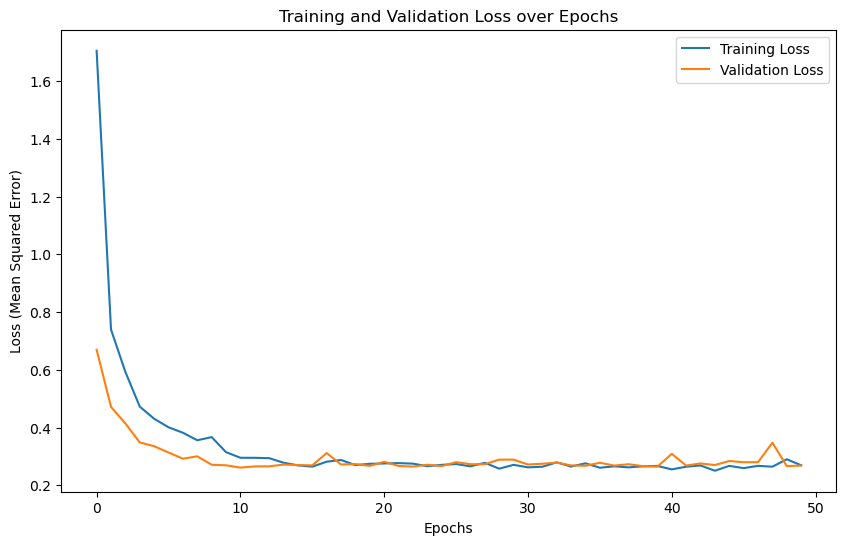

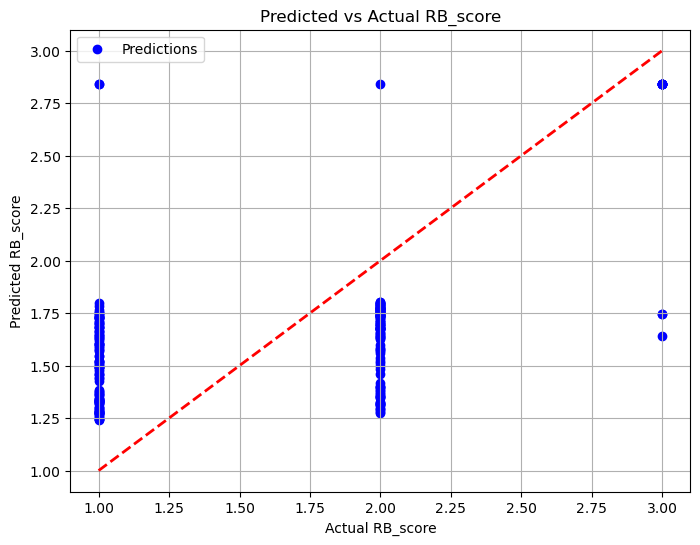

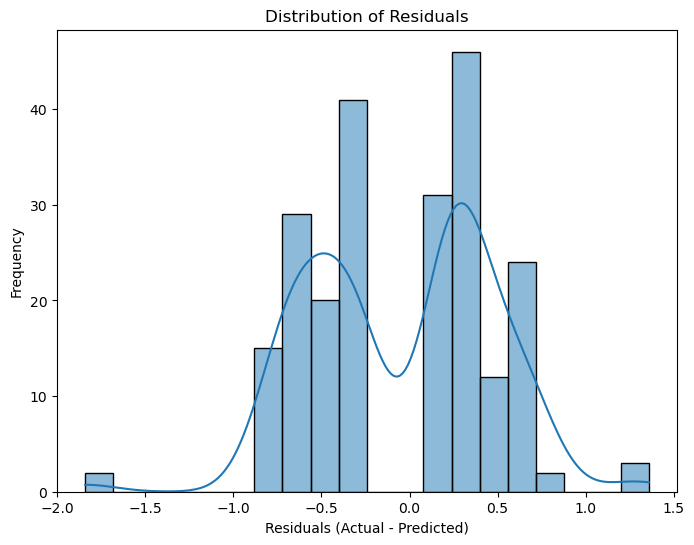

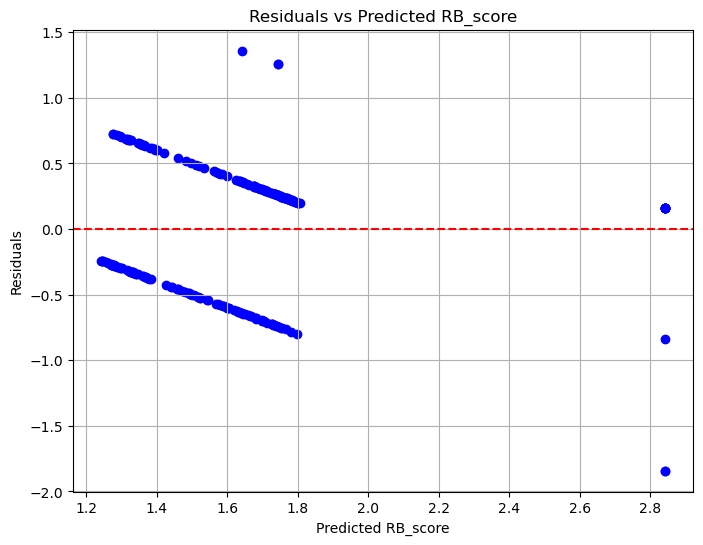

In [132]:
# Step 1: Prepare the data
max_length = 15  # Define the maximum length for padding

# Pad the `trunc_layers_above_wl` and `trunc_density_above_wl` arrays for input
X_layers = pad_sequences(df_raw['trunc_layers_above_wl'].tolist(), maxlen=max_length, padding='post', value=0.0)
X_density = pad_sequences(df_raw['trunc_density_above_wl'].tolist(), maxlen=max_length, padding='post', value=0.0)

# Stack the two input features into one 3D array (samples, timesteps, features)
X_combined = np.stack((X_layers, X_density), axis=2)

# Rename target variable
target_rb_score = df_raw['RB_score_grouped'].values  # Unique name for the target variable

# Split data into 70% training and 30% validation
X_train, X_test, y_train, y_test = train_test_split(X_combined, target_rb_score, test_size=0.3, random_state=42)

# Step 2: Define the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 3: Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Step 4: Predict on the test data
y_pred = model.predict(X_test)

# Step 5: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse}')

# Step 6: Plot Loss Graph - Show how loss decreases over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()

# Step 7: Predicted vs Actual Values - Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line for perfect prediction
plt.title('Predicted vs Actual RB_score')
plt.xlabel('Actual RB_score')
plt.ylabel('Predicted RB_score')
plt.legend()
plt.grid(True)
plt.show()

# Step 8: Convert y_test to numeric if it's categorical or object
y_test = pd.to_numeric(y_test, errors='coerce')

# Make sure y_pred is a flat array for subtraction
y_pred = y_pred.flatten()

# Step 9: Residual Plot - Errors between predicted and actual values
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=20, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

# Optionally: Residuals vs Predicted Values
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, c='blue', marker='o', label='Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted RB_score')
plt.xlabel('Predicted RB_score')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()
